# Membership EDA — 로컬 버전
**목적:** Membership.csv 탐색적 데이터 분석  
**데이터:** `../data/Membership.csv`, `../data/Description.xlsx`  
**분석 구조:** 전체 고객 기본 분석 → 이상치 → 분포 → 시계열 → 세그먼트별 비교 → 교차분석 → 상관관계

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import missingno as msno
import warnings
import os, platform
warnings.filterwarnings('ignore')

# 한글 폰트
if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')
    fm._load_fontmanager(try_read_cache=False)
    nanum = [f for f in fm.findSystemFonts() if 'Nanum' in f or 'nanum' in f]
    if nanum:
        fm.fontManager.addfont(nanum[0])
        plt.rcParams['font.family'] = fm.FontProperties(fname=nanum[0]).get_name()

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
print('환경:', platform.system(), '/ 폰트:', plt.rcParams['font.family'])

환경: Windows / 폰트: ['Malgun Gothic']


## 1. 데이터 로드

In [2]:
DATA_DIR = '../data/'

mem  = pd.read_csv(DATA_DIR + 'Membership.csv')
desc = pd.read_excel(DATA_DIR + 'Description.xlsx')

# 파생 컬럼 생성
mem['reg_date']      = pd.to_datetime(mem['reg_date'])
mem['end_date']      = pd.to_datetime(mem['end_date'])
mem['duration_days'] = (mem['end_date'] - mem['reg_date']).dt.days

print(f'Membership shape : {mem.shape}')
print(f'컬럼 목록 : {list(mem.columns)}')

Membership shape : (18183, 16)
컬럼 목록 : ['user_no', 'product_cd', 'amount', 'billing_method', 'concurrent_streams', 'promotion_yn', 'is_churn_prevented', 'repurchase', 'payment_device', 'is_user_verified', 'gender', 'age', 'reg_date', 'reg_hour', 'end_date', 'duration_days']


In [3]:
# 컬럼 설명 확인
desc[['Name', 'Description', 'Example']]

,Name,Description,Example
0,user_no,User 식별값,9c1c04380d3ec71c9ea55cb99ad803ab7c0037a3482b9b...
1,product_cd,가입상품코드,pk_1487
2,amount,실결제 금액,100
3,billing_method,결제 수단,190
4,concurrent_streams,동시 시청 가능수,1
5,promotion_yn,100원 프로모션 참여여부(첫달100원),O
6,is_churn_prevented,해지방어 적립여부 (해지신청시 포인트 증정후 해지 철회),NaN
7,repurchase,재결제 여부(Y),NaN
8,payment_device,결제기기,mobile
9,is_user_verified,본인인증여부 (미인증시 성별/연령 부정확),Y


## 2-0. 전체 컬럼 값 종류 확인

In [4]:
for col in mem.columns:
    n_unique = mem[col].nunique(dropna=False)
    n_null   = mem[col].isnull().sum()
    dtype    = mem[col].dtype
    vals     = mem[col].value_counts(dropna=False)
    print(f"=" * 60)
    print(f"[{col}]  dtype={dtype}  unique={n_unique}  결측={n_null}")
    if n_unique <= 20:
        print(vals.to_string())
    else:
        print("  상위 10개:")
        print(vals.head(10).to_string())
        print(f"  ... 외 {n_unique - 10}개")
    print()


[user_no]  dtype=object  unique=17845  결측=0
  상위 10개:
user_no
a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c362622171c550dcfe7099733a95d986e379eedfcb8edb5adc79c3f2439a56104f63410b83a10131c8ea5    7
30e3c9509b8d6102f80906a80afcd2a3593d4a69314509227839d972bc051a4c2411cac5aa2fabd6069781c5971ec4eec237a88cad2701712ba7806c533da7b8    7
1f6524f746f0361cd5cf706f0777b6e3ba6a68bd6a86123742733d140f7020d3a04caf6edf3c9a6ec52d7b34751ce1dd2225657d602a6be176ea2c87d30d1010    6
9f0e82544e63feb3fbd0eeb81c749932f9aa0be13d5082805cae93dadda5277be3bc4bbdc8af145edab5d890b53b4768e15d2358d58dfb76bb509ad430f732a2    5
6513fff57e32407ab087206e57186ee4cbde4888a5f79702f9caee7d23d008d30360c95fe000694668cd0c5fd557fb0e1a6d4473abbb18652a717ebf2d5c471e    5
412fe59a8f5ed105d97c6370f0113053f03efb04890b6814370720be519ee6b48803db2cf8ba59dde3825ff1c2d49765a93b31d2aecd81715ae0a392df3cf146    4
6bd93123dd50f0e428fda65dc0c77c6f84da82a10b7f2607d4ccc67e1b51699d7f376c2bb4d017e3c057089a665fb45b99c3d0748f727dfc81d590fb23e3aafe    4


## 2. 데이터 품질 점검

### 2-1. 기본 정보

In [5]:
mem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_no             18183 non-null  object        
 1   product_cd          18183 non-null  object        
 2   amount              18183 non-null  float64       
 3   billing_method      18183 non-null  int64         
 4   concurrent_streams  18113 non-null  float64       
 5   promotion_yn        9203 non-null   object        
 6   is_churn_prevented  3257 non-null   object        
 7   repurchase          11931 non-null  object        
 8   payment_device      18183 non-null  object        
 9   is_user_verified    17583 non-null  object        
 10  gender              18019 non-null  object        
 11  age                 18019 non-null  float64       
 12  reg_date            18183 non-null  datetime64[ns]
 13  reg_hour            18183 non-null  int64     

In [6]:
mem.describe(include='all')

,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,duration_days
count,18183,18183,18183.000000,18183.000000,18113.000000,9203,3257,11931,18183,17583,18019,18019.000000,18183,18183.000000,18183,18183.000000
unique,17845,53,NaN,NaN,NaN,1,1,1,10,2,3,NaN,NaN,NaN,NaN,NaN
top,a02a14ff1ab86edbfe46ad5a6a7fce054dc83c39aa7c36...,pk_1487,NaN,NaN,NaN,O,O,O,android,Y,F,NaN,NaN,NaN,NaN,NaN
freq,7,6693,NaN,NaN,NaN,9203,3257,11931,8478,13487,9479,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,3032.774402,146.783809,1.699056,NaN,NaN,NaN,NaN,NaN,NaN,33.923359,2021-03-07 13:29:12.780069376,13.597536,2021-04-06 20:54:41.042732032,30.309355
min,NaN,NaN,7.690000,121.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2021-03-01 00:00:00,0.000000,2021-03-01 00:00:00,0.000000
25%,NaN,NaN,100.000000,134.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,2021-03-04 00:00:00,9.000000,2021-04-04 00:00:00,31.000000
50%,NaN,NaN,100.000000,140.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,2021-03-07 00:00:00,15.000000,2021-04-07 00:00:00,31.000000
75%,NaN,NaN,7900.000000,151.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,2021-03-12 00:00:00,20.000000,2021-04-12 00:00:00,31.000000
max,NaN,NaN,16400.000000,190.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,950.000000,2021-03-15 00:00:00,23.000000,2021-04-16 00:00:00,32.000000


### 2-2. 중복 확인

In [7]:
# 전체 행 중복
full_dup = mem.duplicated().sum()
# user_no 기준 중복
userno_dup = mem.duplicated(subset='user_no').sum()

print(f'전체 행 중복 수      : {full_dup}건')
print(f'user_no 중복 수      : {userno_dup}건  ({userno_dup/len(mem)*100:.2f}%)')
print(f'user_no unique 수    : {mem["user_no"].nunique():,}  / 전체 {len(mem):,}')

if userno_dup > 0:
    dup_users = mem[mem.duplicated(subset='user_no', keep=False)]
    print(f'\n중복 user_no 샘플:')
    display(dup_users.sort_values('user_no').head(6))

전체 행 중복 수      : 0건
user_no 중복 수      : 338건  (1.86%)
user_no unique 수    : 17,845  / 전체 18,183

중복 user_no 샘플:


,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,duration_days
12503,01b73db46b0b3f6c24ca22dc4629ed41ed0d6ac4beccf8...,pk_1487,100.00,134,1.0,O,O,NaN,android,Y,F,40.0,2021-03-14,21,2021-03-14,0
13091,01b73db46b0b3f6c24ca22dc4629ed41ed0d6ac4beccf8...,pk_1488,10900.00,134,2.0,NaN,O,NaN,android,Y,F,40.0,2021-03-14,22,2021-04-14,31
13036,0258fd467c5765400d487d203f7c77afb597120daa9b1e...,pk_1506,13.49,140,2.0,NaN,NaN,NaN,ios,N,F,40.0,2021-03-12,5,2021-03-12,0
6647,0258fd467c5765400d487d203f7c77afb597120daa9b1e...,pk_1508,9.99,140,1.0,NaN,NaN,NaN,ios,N,F,40.0,2021-03-11,16,2021-04-12,32
8796,03207f956c0a2d363285286b1a9ede62e03373a9242253...,pk_2025,7900.00,151,1.0,NaN,NaN,NaN,android,N,N,40.0,2021-03-13,11,2021-03-13,0
10619,03207f956c0a2d363285286b1a9ede62e03373a9242253...,pk_2026,10900.00,151,2.0,NaN,NaN,O,android,N,N,40.0,2021-03-13,12,2021-04-13,31


### 2-3. 결측치 분석

In [8]:
missing = pd.DataFrame({
    '결측치 수': mem.isnull().sum(),
    '결측 비율(%)': (mem.isnull().sum() / len(mem) * 100).round(2)
}).sort_values('결측치 수', ascending=False)

missing[missing['결측치 수'] > 0]

,결측치 수,결측 비율(%)
is_churn_prevented,14926,82.09
promotion_yn,8980,49.39
repurchase,6252,34.38
is_user_verified,600,3.30
gender,164,0.90
age,164,0.90
concurrent_streams,70,0.38


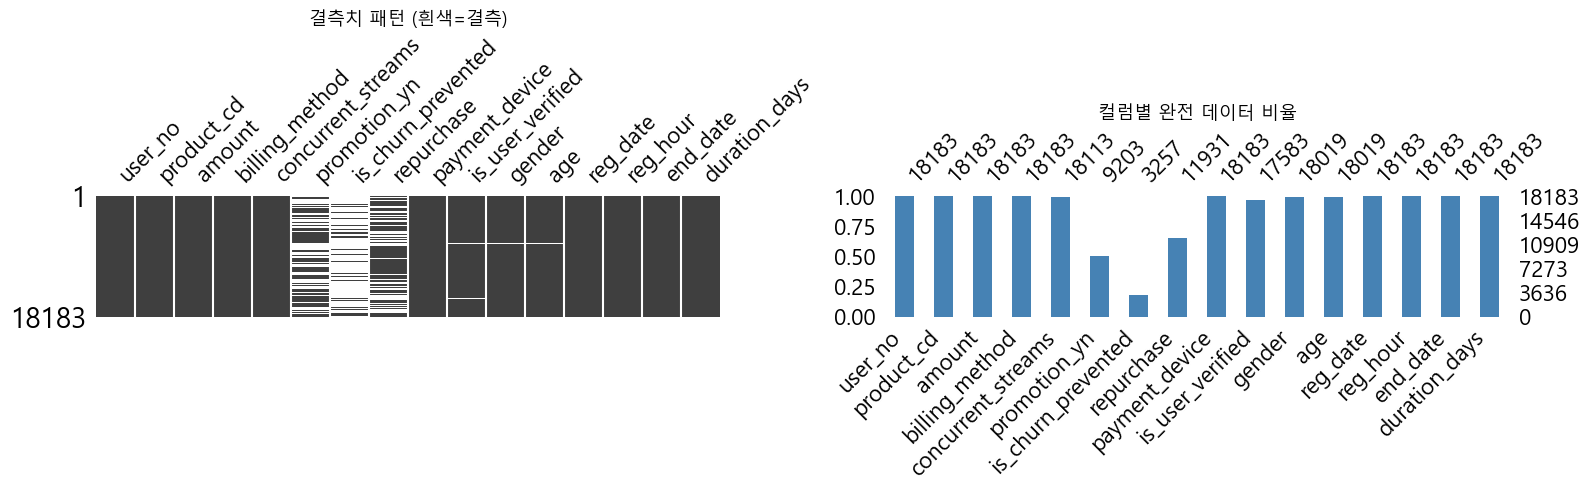

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(mem, ax=axes[0], sparkline=False)
axes[0].set_title('결측치 패턴 (흰색=결측)', fontsize=13)
msno.bar(mem, ax=axes[1], color='steelblue')
axes[1].set_title('컬럼별 완전 데이터 비율', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# promotion_yn / repurchase / is_churn_prevented 결측 패턴 교차 확인
# NaN이 단순 결측인지, 'N(미해당)' 의미인지 검토
print('=== promotion_yn 값 종류 ===')
print(mem['promotion_yn'].value_counts(dropna=False))
print('\n=== repurchase 값 종류 ===')
print(mem['repurchase'].value_counts(dropna=False))
print('\n=== is_churn_prevented 값 종류 ===')
print(mem['is_churn_prevented'].value_counts(dropna=False))
print('\n→ 세 컬럼 모두 값이 O 하나뿐 → NaN은 N(미해당) 의미로 해석 가능')

=== promotion_yn 값 종류 ===
promotion_yn
O      9203
NaN    8980
Name: count, dtype: int64

=== repurchase 값 종류 ===
repurchase
O      11931
NaN     6252
Name: count, dtype: int64

=== is_churn_prevented 값 종류 ===
is_churn_prevented
NaN    14926
O       3257
Name: count, dtype: int64

→ 세 컬럼 모두 값이 O 하나뿐 → NaN은 N(미해당) 의미로 해석 가능


### 2-4. 값 이상 확인

In [11]:
# age 이상값
print('=== age 분포 ===')
print(mem['age'].describe())
print(f'\nage == 0 : {(mem["age"] == 0).sum()}건')
print(f'age >= 100 : {(mem["age"] >= 100).sum()}건')
print('\nage 100 이상 케이스:')
display(mem[mem['age'] >= 100][['user_no','age','is_user_verified','gender']].head(10))

# amount 이상값
print('\n=== amount 이상값 ===')
print(f'0원 이하 : {(mem["amount"] <= 0).sum()}건')
print(f'최솟값   : {mem["amount"].min()}원')
print(f'10원 미만: {(mem["amount"] < 10).sum()}건')
display(mem[mem['amount'] < 10][['user_no','product_cd','amount','billing_method']].head())

# reg_date > end_date 케이스
invalid_date = mem[mem['reg_date'] > mem['end_date']]
print(f'\nreg_date > end_date : {len(invalid_date)}건')

# duration_days 음수 or 0
print(f'duration_days == 0 (당일 해지) : {(mem["duration_days"] == 0).sum()}건')
print(f'duration_days < 0 : {(mem["duration_days"] < 0).sum()}건')

=== age 분포 ===
count    18019.000000
mean        33.923359
std         12.606441
min          0.000000
25%         25.000000
50%         35.000000
75%         40.000000
max        950.000000
Name: age, dtype: float64

age == 0 : 5건
age >= 100 : 2건

age 100 이상 케이스:


,user_no,age,is_user_verified,gender
5529,c2965f476564ba6e82061bfff3437d238a665a562be040...,950.0,N,N
10345,c5e66373e9d542412c3e83f3c664bf6d87edec5e957f07...,120.0,N,N



=== amount 이상값 ===
0원 이하 : 0건
최솟값   : 7.69원
10원 미만: 2137건


,user_no,product_cd,amount,billing_method
3,445fb8813626d3d49b94b5be58cd76d80ed31fa94f8372...,pk_1508,9.99,140
9,1d47cdbe7f7016e6c3f42cb08e37db55548481ffa31122...,pk_1508,9.99,140
18,55dde00cc04d57b986d5bd9ae14fa9c5bde7c6005fa478...,pk_1508,9.99,140
26,c1f7ae1eaebdd5cdd89f308c424154b2f900c4f758fb64...,pk_1508,9.99,140
27,6d45315d362a00f79ee58e71c8f5f53221dd01b9816370...,pk_1508,9.99,140



reg_date > end_date : 0건
duration_days == 0 (당일 해지) : 399건
duration_days < 0 : 0건


## 3. 이상치 분석 (Boxplot + IQR)

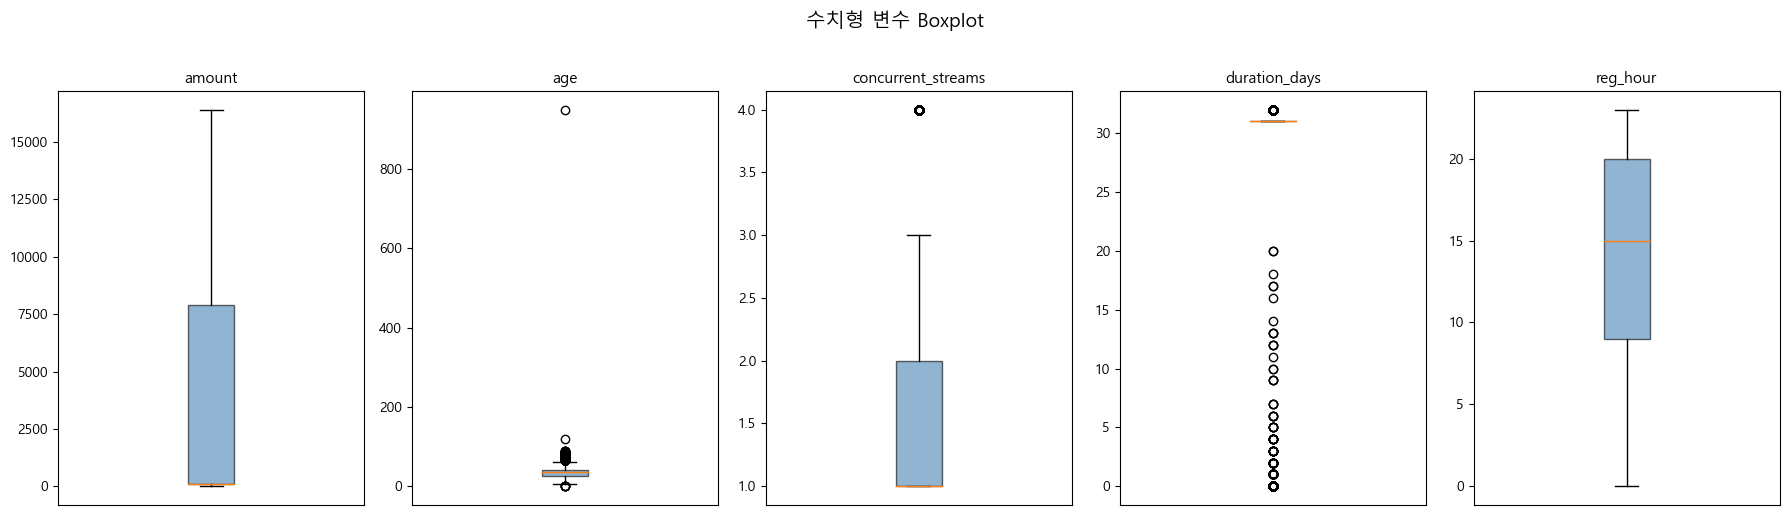

In [12]:
num_cols = ['amount', 'age', 'concurrent_streams', 'duration_days', 'reg_hour']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    ax.boxplot(mem[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=11)
    ax.set_xticks([])
plt.suptitle('수치형 변수 Boxplot', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# IQR 기반 이상치 탐지
iqr_results = []
for col in num_cols:
    q1 = mem[col].quantile(0.25)
    q3 = mem[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = mem[(mem[col] < lower) | (mem[col] > upper)][col]
    iqr_results.append({
        '컬럼': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        '하한': lower, '상한': upper,
        '이상치 수': len(outliers),
        '이상치 비율(%)': round(len(outliers)/len(mem)*100, 2)
    })

pd.DataFrame(iqr_results).set_index('컬럼')

,Q1,Q3,IQR,하한,상한,이상치 수,이상치 비율(%)
컬럼,,,,,,,
amount,100.0,7900.0,7800.0,-11600.0,19600.0,0,0.00
age,25.0,40.0,15.0,2.5,62.5,246,1.35
concurrent_streams,1.0,2.0,1.0,-0.5,3.5,2948,16.21
duration_days,31.0,31.0,0.0,31.0,31.0,3441,18.92
reg_hour,9.0,20.0,11.0,-7.5,36.5,0,0.00


## 4. 수치형 변수 분포

### 4-1. amount (결제 금액)

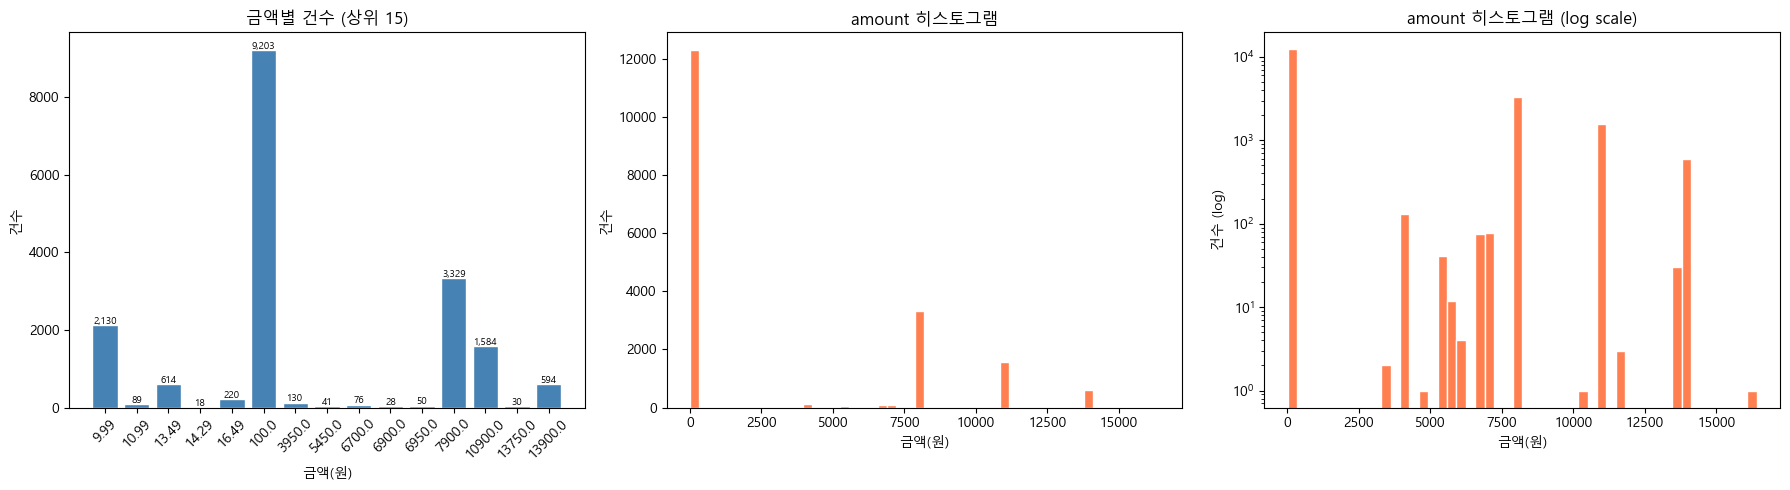

count    18183.000000
mean      3032.774402
std       4456.244413
min          7.690000
25%        100.000000
50%        100.000000
75%       7900.000000
max      16400.000000
Name: amount, dtype: float64

100원 이하 건수 : 12,297건 (67.6%)  → 100원 프로모션 참여자


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 금액별 건수 (상위 15)
top_amt = mem['amount'].value_counts().head(15).sort_index()
axes[0].bar(top_amt.index.astype(str), top_amt.values, color='steelblue', edgecolor='white')
axes[0].set_title('금액별 건수 (상위 15)', fontsize=12)
axes[0].set_xlabel('금액(원)')
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(top_amt.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=7)

# 히스토그램
axes[1].hist(mem['amount'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('amount 히스토그램', fontsize=12)
axes[1].set_xlabel('금액(원)')
axes[1].set_ylabel('건수')

# 로그 스케일
axes[2].hist(mem['amount'], bins=50, color='coral', edgecolor='white', log=True)
axes[2].set_title('amount 히스토그램 (log scale)', fontsize=12)
axes[2].set_xlabel('금액(원)')
axes[2].set_ylabel('건수 (log)')

plt.tight_layout()
plt.show()

print(mem['amount'].describe())
print(f'\n100원 이하 건수 : {(mem["amount"] <= 100).sum():,}건 ({(mem["amount"] <= 100).mean()*100:.1f}%)  → 100원 프로모션 참여자')

### 4-2. age (연령대)

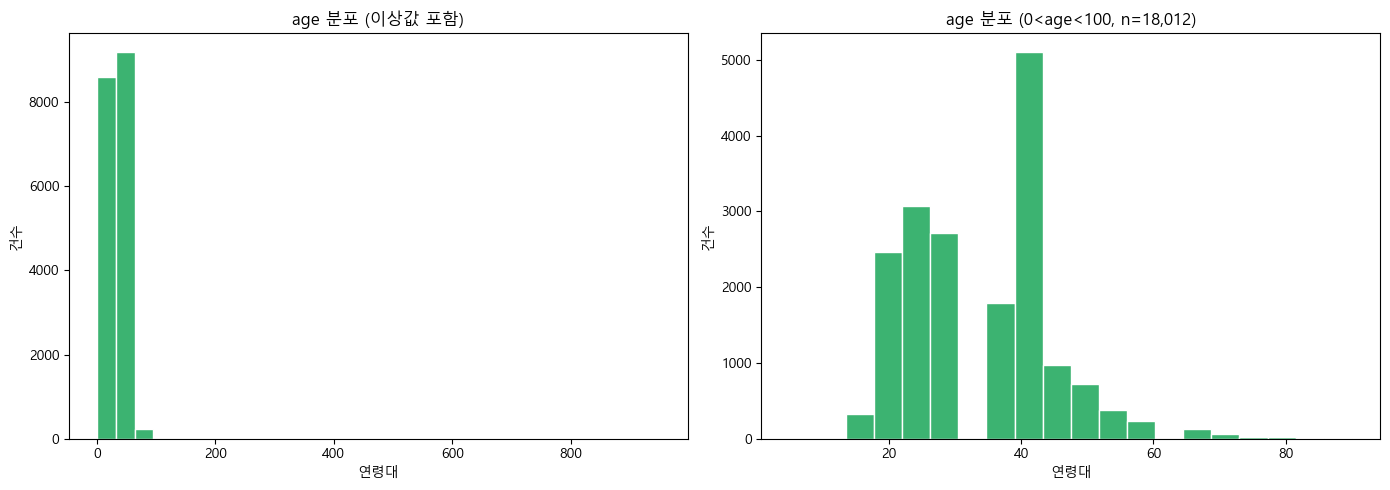

count    18019.000000
mean        33.923359
std         12.606441
min          0.000000
25%         25.000000
50%         35.000000
75%         40.000000
max        950.000000
Name: age, dtype: float64

age == 0   : 5건  → is_user_verified 확인 필요
age >= 100 : 2건  → 이상값 의심


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 (이상값 포함)
age_all = mem['age'].dropna()
axes[0].hist(age_all, bins=30, color='mediumseagreen', edgecolor='white')
axes[0].set_title('age 분포 (이상값 포함)', fontsize=12)
axes[0].set_xlabel('연령대')
axes[0].set_ylabel('건수')

# 이상값 제외 (0~100 미만)
age_clean = mem[(mem['age'] > 0) & (mem['age'] < 100)]['age']
axes[1].hist(age_clean, bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title(f'age 분포 (0<age<100, n={len(age_clean):,})', fontsize=12)
axes[1].set_xlabel('연령대')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.show()

print(mem['age'].describe())
print(f'\nage == 0   : {(mem["age"] == 0).sum()}건  → is_user_verified 확인 필요')
print(f'age >= 100 : {(mem["age"] >= 100).sum()}건  → 이상값 의심')

### 4-2-1. age=40 spike 상세 분석
> age=40이 5,104건으로 비정상적 spike — 미인증 기본값 여부와 관련 변수(gender, iOS, is_user_verified) 교차 확인

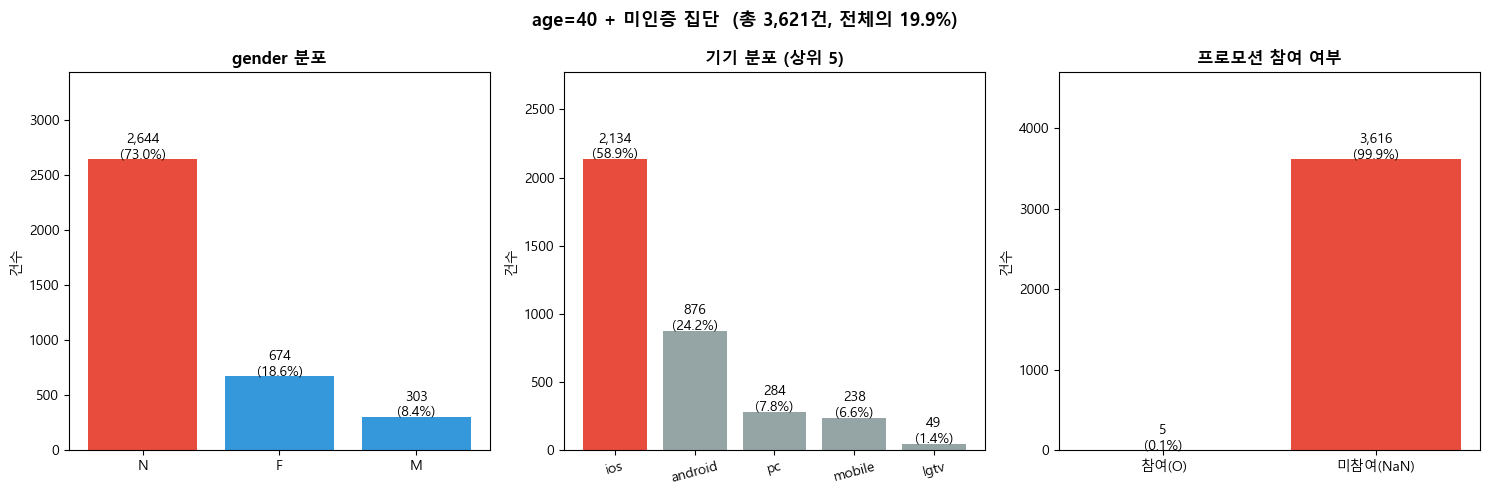

In [16]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

target = mem[(mem["age"] == 40) & (mem["is_user_verified"] == "N")]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"age=40 + 미인증 집단  (총 {len(target):,}건, 전체의 {len(target)/len(mem)*100:.1f}%)",
    fontsize=13, fontweight="bold")

# 1. gender
ax = axes[0]
gcnt = target["gender"].value_counts()
bar_c = ["#e74c3c" if x == "N" else "#3498db" for x in gcnt.index]
bars = ax.bar(gcnt.index, gcnt.values, color=bar_c)
ax.set_title("gender 분포", fontweight="bold"); ax.set_ylabel("건수")
for b in bars:
    pct = b.get_height() / len(target) * 100
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
            f"{int(b.get_height()):,}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_ylim(0, gcnt.max()*1.3)

# 2. payment_device
ax = axes[1]
dcnt = target["payment_device"].value_counts().head(5)
bar_c = ["#e74c3c" if x == "ios" else "#95a5a6" for x in dcnt.index]
bars = ax.bar(range(len(dcnt)), dcnt.values, color=bar_c)
ax.set_title("기기 분포 (상위 5)", fontweight="bold"); ax.set_ylabel("건수")
ax.set_xticks(range(len(dcnt))); ax.set_xticklabels(dcnt.index, rotation=15)
for b in bars:
    pct = b.get_height() / len(target) * 100
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
            f"{int(b.get_height()):,}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_ylim(0, dcnt.max()*1.3)

# 3. promotion_yn
ax = axes[2]
p_vals = [(target["promotion_yn"] == "O").sum(), target["promotion_yn"].isna().sum()]
p_lbls = ["참여(O)", "미참여(NaN)"]
bars = ax.bar(p_lbls, p_vals, color=["#2ecc71", "#e74c3c"])
ax.set_title("프로모션 참여 여부", fontweight="bold"); ax.set_ylabel("건수")
for b in bars:
    pct = b.get_height() / len(target) * 100
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+10,
            f"{int(b.get_height()):,}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_ylim(0, max(p_vals)*1.3)

plt.tight_layout()
plt.show()


### 4-2-2. age 전처리 — age=40·미인증 기본값 대체
> age=40 + 미인증(3,621건) 중 초과분 3,245건을 NaN 처리 후 **인증 유저 나이 비율대로 정확히 배분** (자연비율 376건 유지)

인증 유저 내 age=40 자연비율: 10.37%
미인증 age=40: 3,621건 → 376건 유지 / 3,245건 NaN 처리
NaN 처리 대상: 이상값 2건 + 결측 164건 + age=40 초과분 3,245건 = 3,411건
비율 배분 완료: 3411건 → 결측 0건 (처리 후 결측: 0건)


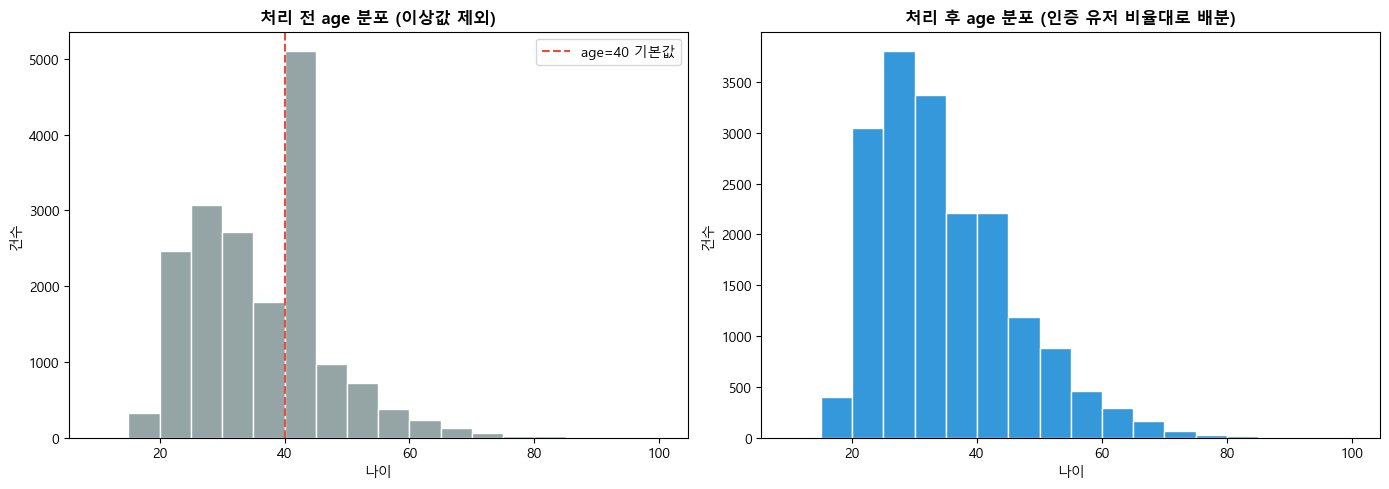

In [17]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── age 전처리 ─────────────────────────────────────────────
# 처리 방침:
#   1) age > 100 이상값 (2건) → NaN
#   2) age 결측 (150건) → NaN
#   3) age=40 + 미인증 중 초과분 3,245건 → NaN
#      - 인증 유저 내 age=40 자연비율 10.37% 적용
#      - 376건은 실제 40대로 유지
#   4) 전체 NaN → 인증 유저 나이 비율대로 정확히 배분

mask_outlier = mem["age"] > 100
mask_missing = mem["age"].isna()

# age=40 미인증 초과분 계산
verified_age40_rate = (mem[mem["is_user_verified"] == "Y"]["age"] == 40).mean()
age40_unv_idx = mem[(mem["age"] == 40) & (mem["is_user_verified"] == "N")].index
n_keep = round(len(age40_unv_idx) * verified_age40_rate)
n_replace = len(age40_unv_idx) - n_keep
replace_idx = age40_unv_idx.to_series().sample(n=n_replace, random_state=42).index
mask_default = mem.index.isin(replace_idx)

print(f"인증 유저 내 age=40 자연비율: {verified_age40_rate*100:.2f}%")
print(f"미인증 age=40: {len(age40_unv_idx):,}건 → {n_keep}건 유지 / {n_replace:,}건 NaN 처리")

n_outlier = mask_outlier.sum()
n_missing = mask_missing.sum()
print(f"NaN 처리 대상: 이상값 {n_outlier}건 + 결측 {n_missing}건 + age=40 초과분 {n_replace:,}건 = {n_outlier+n_missing+n_replace:,}건")

mem_proc = mem.copy()
mem_proc.loc[mask_outlier | mask_missing | mask_default, "age"] = float("nan")

# ── 인증 유저 나이 비율대로 정확히 배분 ──────────────────────
verified_ages = mem_proc[mem_proc["is_user_verified"] == "Y"]["age"].dropna()
age_ratio = verified_ages.value_counts(normalize=True).sort_index()

nan_idx = mem_proc[mem_proc["age"].isna()].index
n_nan = len(nan_idx)

# 비율 × n_nan → 정수 배분 (나머지는 반올림 오차 보정)
counts = (age_ratio * n_nan).round().astype(int)
diff = n_nan - counts.sum()
if diff != 0:
    # 오차 보정: 가장 큰 비율 항목에 diff 추가
    counts.iloc[counts.argmax()] += diff

assigned = []
for age_val, cnt in counts.items():
    assigned.extend([age_val] * cnt)

import random
random.seed(42)
random.shuffle(assigned)

mem_proc.loc[nan_idx, "age"] = assigned

print(f"비율 배분 완료: {n_nan}건 → 결측 0건 (처리 후 결측: {mem_proc['age'].isna().sum()}건)")

# ── 처리 전후 분포 비교 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = list(range(10, 101, 5))

axes[0].hist(mem["age"].dropna().clip(upper=100), bins=bins, color="#95a5a6", edgecolor="white")
axes[0].set_title("처리 전 age 분포 (이상값 제외)", fontweight="bold")
axes[0].set_xlabel("나이"); axes[0].set_ylabel("건수")
axes[0].axvline(40, color="#e74c3c", linestyle="--", linewidth=1.5, label="age=40 기본값")
axes[0].legend()

axes[1].hist(mem_proc["age"].dropna(), bins=bins, color="#3498db", edgecolor="white")
axes[1].set_title("처리 후 age 분포 (인증 유저 비율대로 배분)", fontweight="bold")
axes[1].set_xlabel("나이"); axes[1].set_ylabel("건수")

plt.tight_layout()
plt.show()


### 4-2-3. gender 전처리 — N·결측 → F/M 비율 배분
> N(미확인 2,749건) + 결측(152건) = 2,901건을 F/M 비율(F 62.56% / M 37.44%)로 **비율대로 정확히 배분**

N(2,849건) + NaN(164건) = 3,013건 → F/M 비율 배분
  F: 1,883건 추가 / M: 1,130건 추가

처리 후: F 11,362건 (62.5%) / M 6,821건 (37.5%)


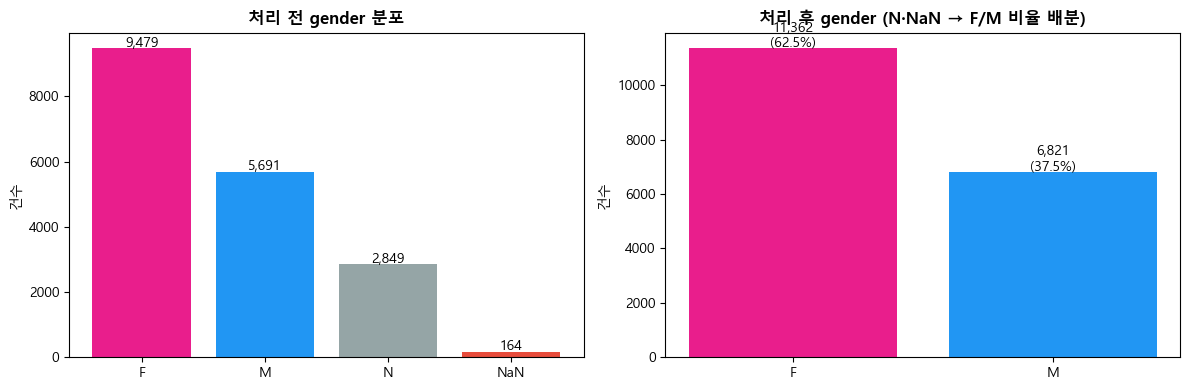

In [18]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

import random

# ── gender 전처리 ─────────────────────────────────────────
# N(미확인) + NaN(결측) 모두 F/M 비율대로 배분
# F/M 비율: F 62.56% / M 37.44% (N·NaN 제외한 인증 성별 기준)

before_g = mem["gender"].value_counts(dropna=False)

# N + NaN → F/M 비율로 대체
fm_ratio = mem[mem["gender"].isin(["F", "M"])]["gender"].value_counts(normalize=True)
replace_mask = mem["gender"].isin(["N"]) | mem["gender"].isna()
n_replace = replace_mask.sum()

counts = (fm_ratio * n_replace).round().astype(int)
diff = n_replace - counts.sum()
if diff != 0:
    counts.iloc[counts.values.argmax()] += diff

assigned = []
for gv, cnt in counts.items():
    assigned.extend([gv] * int(cnt))

random.seed(42)
random.shuffle(assigned)

mem_proc_g = mem.copy()
mem_proc_g.loc[replace_mask[replace_mask].index, "gender"] = assigned

print(f"N({before_g.get('N', 0):,}건) + NaN({mem['gender'].isna().sum()}건) = {n_replace:,}건 → F/M 비율 배분")
print(f"  F: {counts.get('F', 0):,}건 추가 / M: {counts.get('M', 0):,}건 추가")

after_g = mem_proc_g["gender"].value_counts().sort_index()
print(f"\n처리 후: F {after_g.get('F',0):,}건 ({after_g.get('F',0)/after_g.sum()*100:.1f}%) / M {after_g.get('M',0):,}건 ({after_g.get('M',0)/after_g.sum()*100:.1f}%)")

# 처리 전후 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"F": "#e91e8c", "M": "#2196f3", "N": "#95a5a6", "NaN": "#e74c3c"}

lbls_b = [str(x) if x == x else "NaN" for x in before_g.index]
axes[0].bar(lbls_b, before_g.values, color=[colors.get(l, "#aaa") for l in lbls_b])
axes[0].set_title("처리 전 gender 분포", fontweight="bold")
axes[0].set_ylabel("건수")
for i, v in enumerate(before_g.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10)

after_lbls = list(after_g.index)
axes[1].bar(after_lbls, after_g.values, color=[colors.get(l, "#aaa") for l in after_lbls])
axes[1].set_title("처리 후 gender (N·NaN → F/M 비율 배분)", fontweight="bold")
axes[1].set_ylabel("건수")
for i, v in enumerate(after_g.values):
    pct = v / after_g.sum() * 100
    axes[1].text(i, v + 50, f"{v:,}\n({pct:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


### 4-3. concurrent_streams (동시 시청 수)

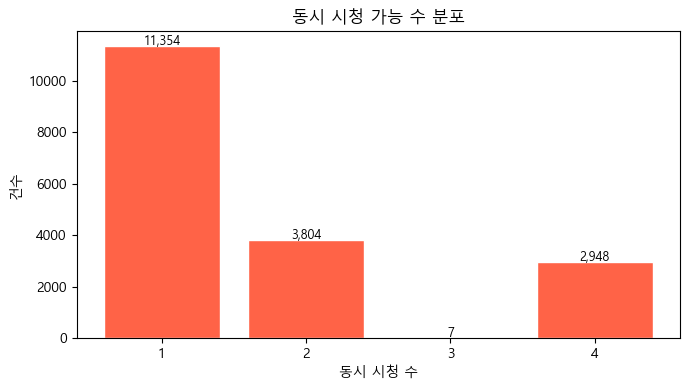

concurrent_streams
1.0    11354
2.0     3804
3.0        7
4.0     2948
Name: count, dtype: int64
결측: 70건


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
sc = mem['concurrent_streams'].value_counts().sort_index()
bars = ax.bar(sc.index.astype(int).astype(str), sc.values,
              color='tomato', edgecolor='white')
ax.set_title('동시 시청 가능 수 분포', fontsize=12)
ax.set_xlabel('동시 시청 수')
ax.set_ylabel('건수')
for bar, v in zip(bars, sc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(sc)
print(f'결측: {mem["concurrent_streams"].isnull().sum()}건')

### 4-4. reg_hour (가입 시간대)

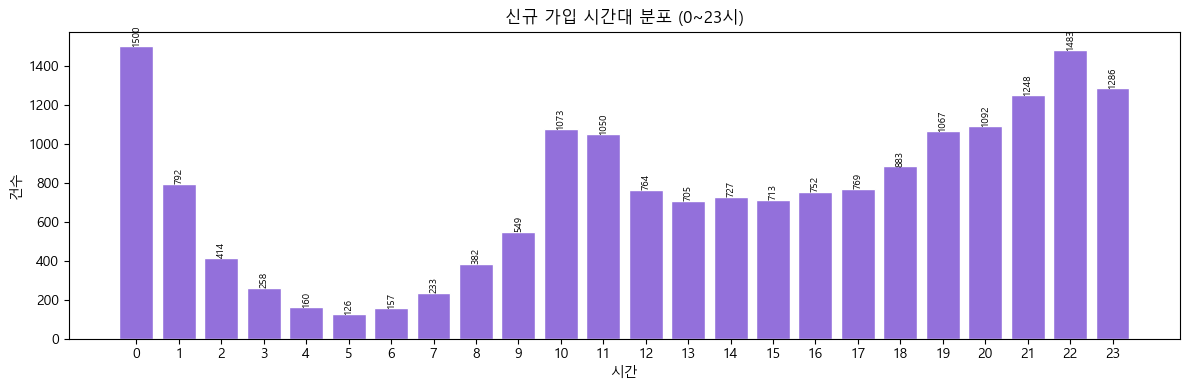

피크 시간대: 0시 (1,500건)
최저 시간대: 5시 (126건)


In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
hour_cnt = mem['reg_hour'].value_counts().sort_index()
bars = ax.bar(hour_cnt.index.astype(str), hour_cnt.values,
              color='mediumpurple', edgecolor='white')
ax.set_title('신규 가입 시간대 분포 (0~23시)', fontsize=12)
ax.set_xlabel('시간')
ax.set_ylabel('건수')
for bar, v in zip(bars, hour_cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{v}', ha='center', fontsize=7, rotation=90)
plt.tight_layout()
plt.show()

print(f'피크 시간대: {hour_cnt.idxmax()}시 ({hour_cnt.max():,}건)')
print(f'최저 시간대: {hour_cnt.idxmin()}시 ({hour_cnt.min():,}건)')

### 4-5. duration_days (멤버십 지속 기간)

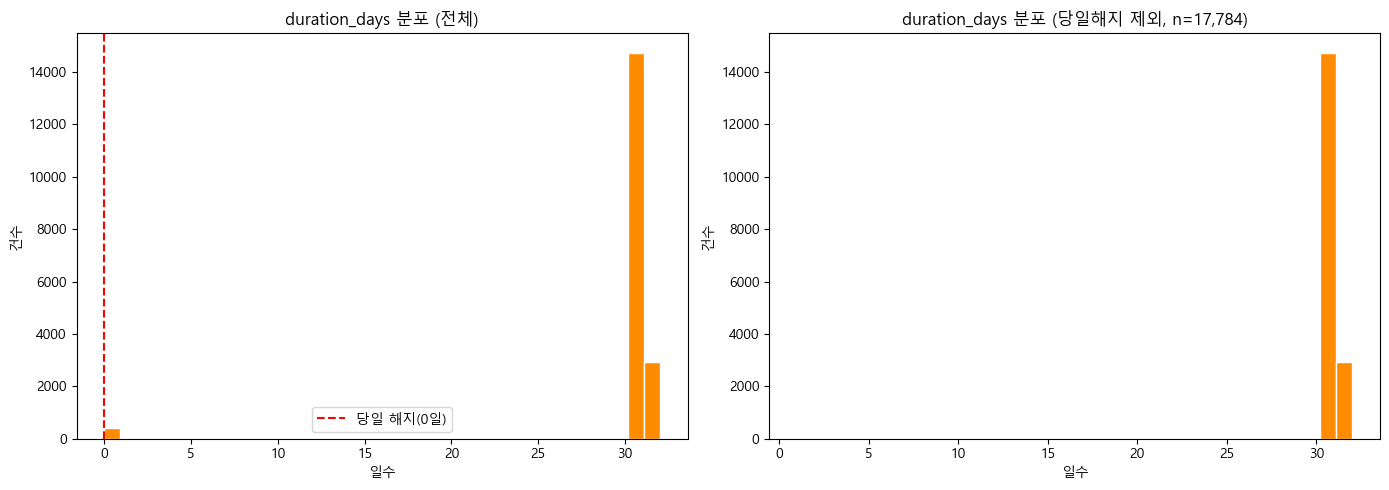

count    18183.000000
mean        30.309355
std          5.050590
min          0.000000
25%         31.000000
50%         31.000000
75%         31.000000
max         32.000000
Name: duration_days, dtype: float64

당일 해지(0일) : 399건 (2.19%)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 (전체)
axes[0].hist(mem['duration_days'], bins=35, color='darkorange', edgecolor='white')
axes[0].set_title('duration_days 분포 (전체)', fontsize=12)
axes[0].set_xlabel('일수')
axes[0].set_ylabel('건수')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='당일 해지(0일)')
axes[0].legend()

# 당일 해지 제외
dur_ex = mem[mem['duration_days'] > 0]['duration_days']
axes[1].hist(dur_ex, bins=35, color='darkorange', edgecolor='white')
axes[1].set_title(f'duration_days 분포 (당일해지 제외, n={len(dur_ex):,})', fontsize=12)
axes[1].set_xlabel('일수')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.show()

print(mem['duration_days'].describe())
print(f'\n당일 해지(0일) : {(mem["duration_days"]==0).sum()}건 ({(mem["duration_days"]==0).mean()*100:.2f}%)')

## 5. 범주형 변수 분포

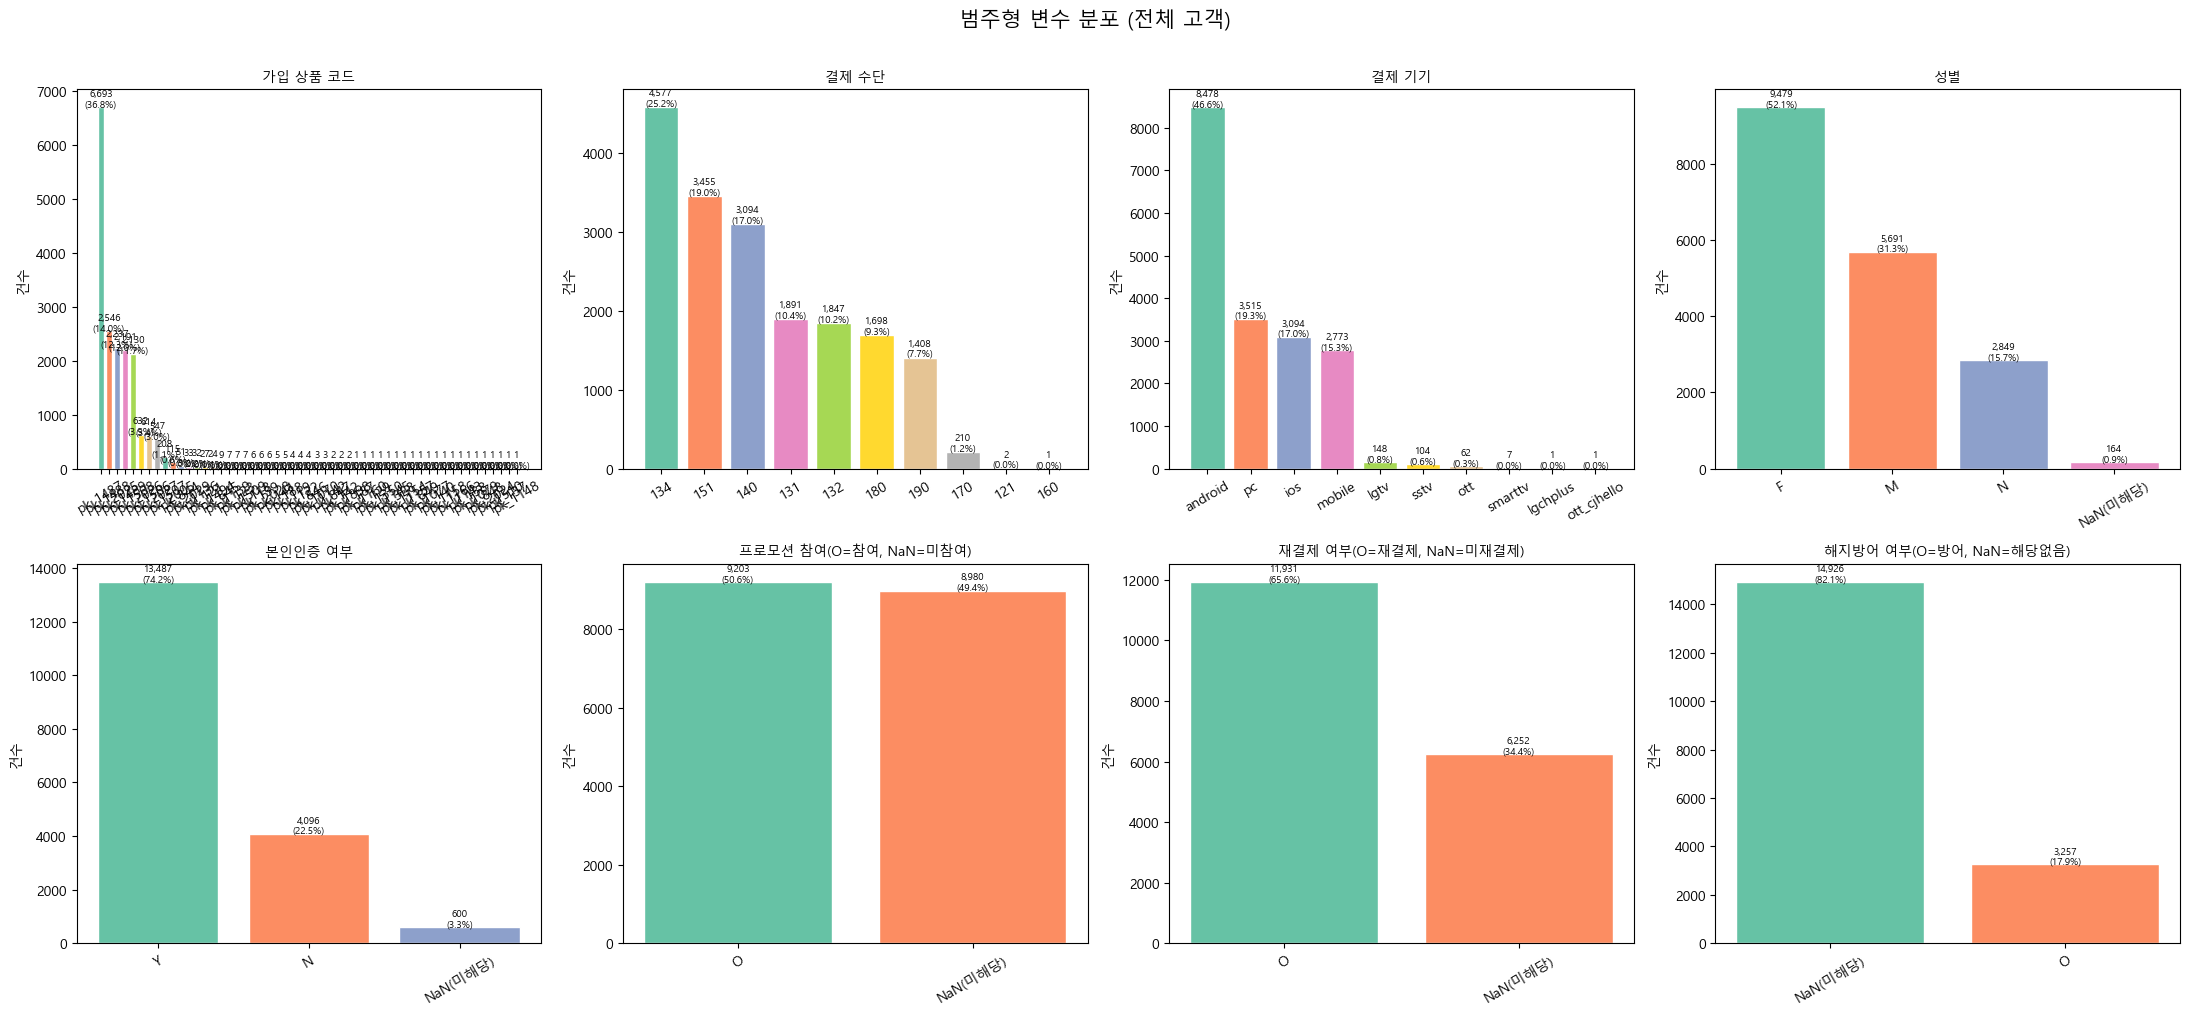

In [22]:
cat_info = {
    'product_cd':         '가입 상품 코드',
    'billing_method':     '결제 수단',
    'payment_device':     '결제 기기',
    'gender':             '성별',
    'is_user_verified':   '본인인증 여부',
    'promotion_yn':       '프로모션 참여(O=참여, NaN=미참여)',
    'repurchase':         '재결제 여부(O=재결제, NaN=미재결제)',
    'is_churn_prevented': '해지방어 여부(O=방어, NaN=해당없음)',
}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
palette = sns.color_palette('Set2')

for i, (col, title) in enumerate(cat_info.items()):
    counts = mem[col].value_counts(dropna=False)
    counts.index = counts.index.astype(str).str.replace('nan', 'NaN(미해당)')
    bars = axes[i].bar(counts.index, counts.values,
                       color=palette[:len(counts)], edgecolor='white')
    axes[i].set_title(title, fontsize=10)
    axes[i].set_ylabel('건수')
    for bar, v in zip(bars, counts.values):
        pct = v / len(mem) * 100
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=7)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('범주형 변수 분포 (전체 고객)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

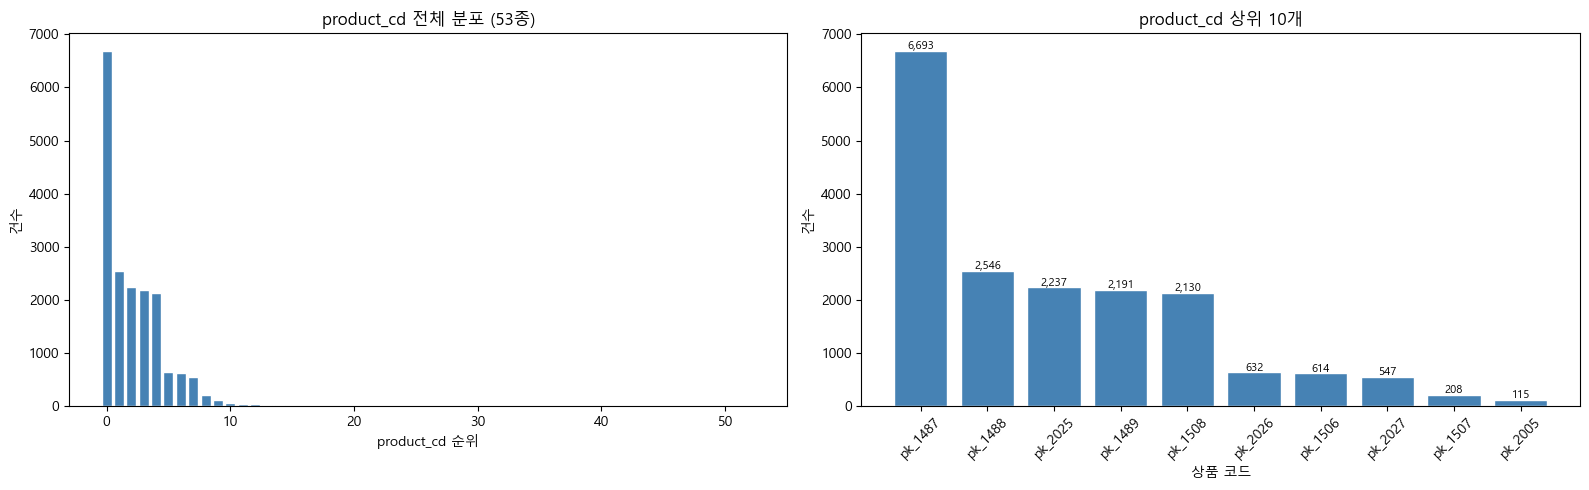

상위 5개 상품이 전체의 86.9% 차지
1건만 있는 상품 수: 21개


In [23]:
# product_cd 상세 — 롱테일 분석
prod_cnt = mem['product_cd'].value_counts()
top5_share = prod_cnt.head(5).sum() / len(mem) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 전체 product_cd 분포
axes[0].bar(range(len(prod_cnt)), prod_cnt.values, color='steelblue', edgecolor='white')
axes[0].set_title(f'product_cd 전체 분포 ({len(prod_cnt)}종)', fontsize=12)
axes[0].set_xlabel('product_cd 순위')
axes[0].set_ylabel('건수')

# 상위 10개
top10 = prod_cnt.head(10)
axes[1].bar(top10.index, top10.values, color='steelblue', edgecolor='white')
axes[1].set_title('product_cd 상위 10개', fontsize=12)
axes[1].set_xlabel('상품 코드')
axes[1].set_ylabel('건수')
axes[1].tick_params(axis='x', rotation=45)
for i, (idx, v) in enumerate(top10.items()):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'상위 5개 상품이 전체의 {top5_share:.1f}% 차지')
print(f'1건만 있는 상품 수: {(prod_cnt == 1).sum()}개')

## 6. 시계열 패턴 분석

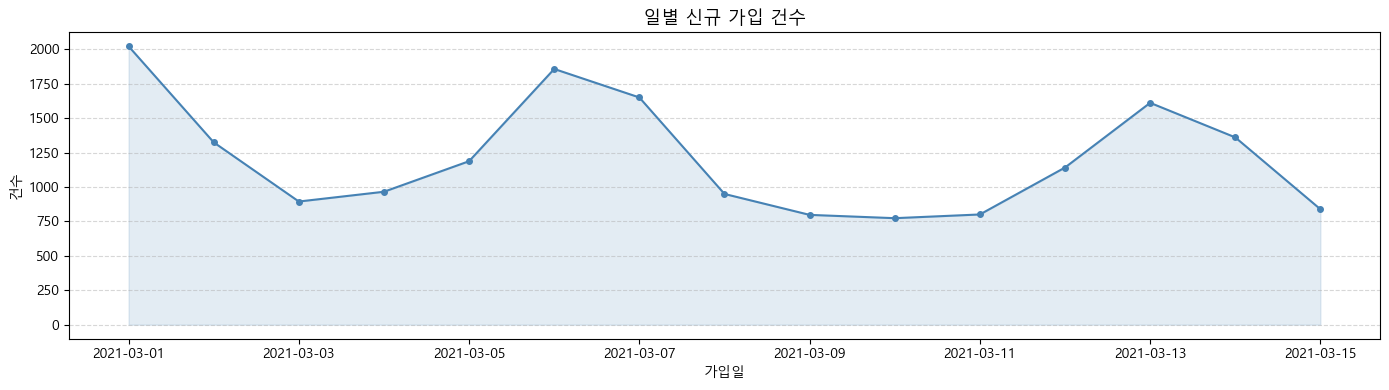

가입일 범위: 2021-03-01 ~ 2021-03-15
가입 피크일: 2021-03-01 (2,023건)


In [24]:
# 일별 가입 추이
daily = mem.groupby('reg_date').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily['reg_date'], daily['count'], marker='o', markersize=4,
        color='steelblue', linewidth=1.5)
ax.fill_between(daily['reg_date'], daily['count'], alpha=0.15, color='steelblue')
ax.set_title('일별 신규 가입 건수', fontsize=13)
ax.set_xlabel('가입일')
ax.set_ylabel('건수')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('가입일 범위:', mem['reg_date'].min().date(), '~', mem['reg_date'].max().date())
print('가입 피크일:', daily.loc[daily['count'].idxmax(), 'reg_date'].date(),
      f"({daily['count'].max():,}건)")

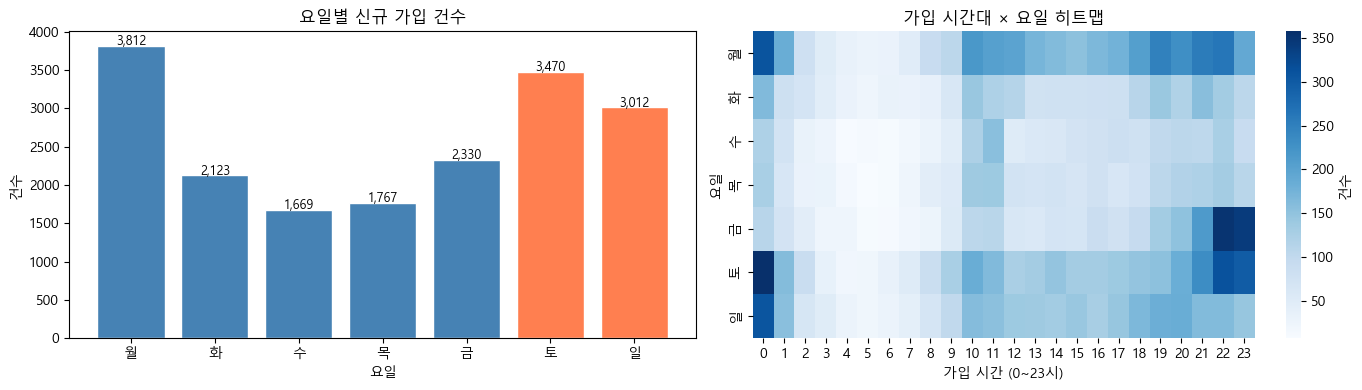

In [25]:
# 요일별 가입 패턴
mem['reg_weekday'] = mem['reg_date'].dt.dayofweek
day_labels = ['월', '화', '수', '목', '금', '토', '일']
weekday_cnt = mem['reg_weekday'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors_wd = ['steelblue']*5 + ['coral']*2  # 주중/주말 구분
bars = axes[0].bar([day_labels[i] for i in weekday_cnt.index],
                   weekday_cnt.values, color=colors_wd, edgecolor='white')
axes[0].set_title('요일별 신규 가입 건수', fontsize=12)
axes[0].set_xlabel('요일')
axes[0].set_ylabel('건수')
for bar, v in zip(bars, weekday_cnt.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{v:,}', ha='center', fontsize=9)

# 시간대 × 요일 히트맵
heatmap_data = mem.groupby(['reg_weekday', 'reg_hour']).size().unstack(fill_value=0)
heatmap_data.index = [day_labels[i] for i in heatmap_data.index]
sns.heatmap(heatmap_data, cmap='Blues', ax=axes[1], cbar_kws={'label': '건수'})
axes[1].set_title('가입 시간대 × 요일 히트맵', fontsize=12)
axes[1].set_xlabel('가입 시간 (0~23시)')
axes[1].set_ylabel('요일')

plt.tight_layout()
plt.show()

## 7. 세그먼트별 분석

각 이진 변수(인증 여부, 프로모션, 재결제, 해지방어)를 기준으로  
**전체 / 세그먼트A / 세그먼트B** 3가지 관점에서 수치형 변수 분포를 비교한다.

In [26]:
def segment_stats(df, label):
    """세그먼트 기본 통계 출력"""
    cols = ['amount', 'age', 'concurrent_streams', 'duration_days']
    available = [c for c in cols if c in df.columns]
    print(f'\n[{label}] n={len(df):,}명')
    display(df[available].describe().round(2))

def plot_segment_dist(seg_dict, col, title, bins=30):
    """세그먼트 3개를 동일 축에 겹쳐서 분포 비교"""
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['steelblue', 'coral', 'mediumseagreen']
    for (label, df), color in zip(seg_dict.items(), colors):
        data = df[col].dropna()
        ax.hist(data, bins=bins, alpha=0.5, label=f'{label} (n={len(df):,})',
                color=color, edgecolor='white', density=True)
    ax.set_title(f'{title} — {col} 분포 비교', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_segment_bar(seg_dict, cat_col, title):
    """세그먼트 3개 범주형 변수 비율 비교"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    colors = sns.color_palette('Set2')
    for ax, (label, df) in zip(axes, seg_dict.items()):
        cnt = df[cat_col].value_counts(dropna=False)
        cnt.index = cnt.index.astype(str).str.replace('nan', 'NaN')
        pcts = cnt / len(df) * 100
        bars = ax.bar(cnt.index, pcts.values, color=colors[:len(cnt)], edgecolor='white')
        ax.set_title(f'{label}\n(n={len(df):,})', fontsize=10)
        ax.set_ylabel('비율(%)')
        ax.set_ylim(0, 100)
        for bar, v in zip(bars, pcts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{v:.1f}%', ha='center', fontsize=8)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle(f'{title} — {cat_col} 비율 비교', fontsize=12)
    plt.tight_layout()
    plt.show()

print('헬퍼 함수 로드 완료')

헬퍼 함수 로드 완료


### 7-1. 본인인증 여부 세그먼트 (전체 / 인증 / 미인증)

> `is_user_verified`: Y=인증, N=미인증  
> **주의:** 미인증 시 age/gender 정보 부정확 (Description 명시)

In [27]:
seg_verified = {
    '전체':  mem,
    '인증(Y)':   mem[mem['is_user_verified'] == 'Y'],
    '미인증(N)': mem[mem['is_user_verified'] == 'N'],
}

print('=== 세그먼트별 기본 현황 ===')
for label, df in seg_verified.items():
    print(f'{label:10s}: {len(df):,}명  ({len(df)/len(mem)*100:.1f}%)')

# 기본 통계
for label, df in seg_verified.items():
    segment_stats(df, label)

=== 세그먼트별 기본 현황 ===
전체        : 18,183명  (100.0%)
인증(Y)     : 13,487명  (74.2%)
미인증(N)    : 4,096명  (22.5%)

[전체] n=18,183명


,amount,age,concurrent_streams,duration_days
count,18183.00,18019.00,18113.00,18183.00
mean,3032.77,33.92,1.70,30.31
std,4456.24,12.61,1.09,5.05
min,7.69,0.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,35.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,16400.00,950.00,4.00,32.00



[인증(Y)] n=13,487명


,amount,age,concurrent_streams,duration_days
count,13487.00,13487.00,13462.00,13487.00
mean,2698.69,32.29,1.73,30.51
std,4253.42,11.28,1.11,4.05
min,9.89,15.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,30.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,16400.00,90.00,4.00,32.00



[미인증(N)] n=4,096명


,amount,age,concurrent_streams,duration_days
count,4096.00,4096.00,4056.00,4096.00
mean,4414.01,39.44,1.53,29.82
std,4949.58,14.94,0.94,7.12
min,7.69,15.00,1.00,0.00
25%,9.99,40.00,1.00,31.00
50%,16.49,40.00,1.00,32.00
75%,7900.00,40.00,2.00,32.00
max,13900.00,950.00,4.00,32.00


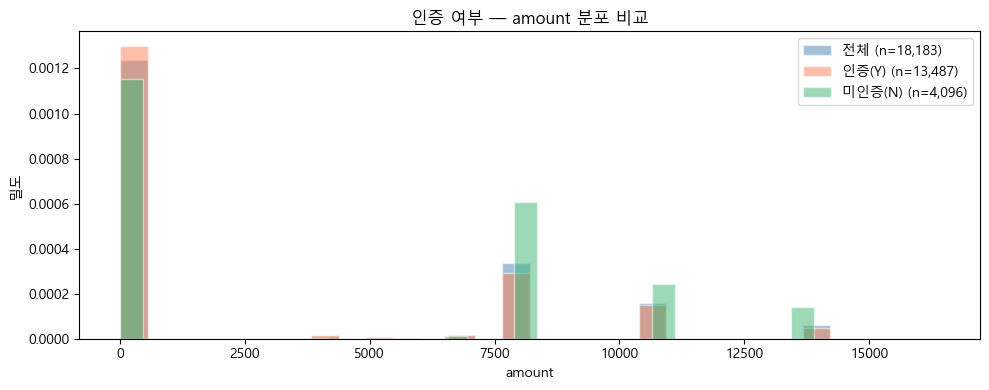

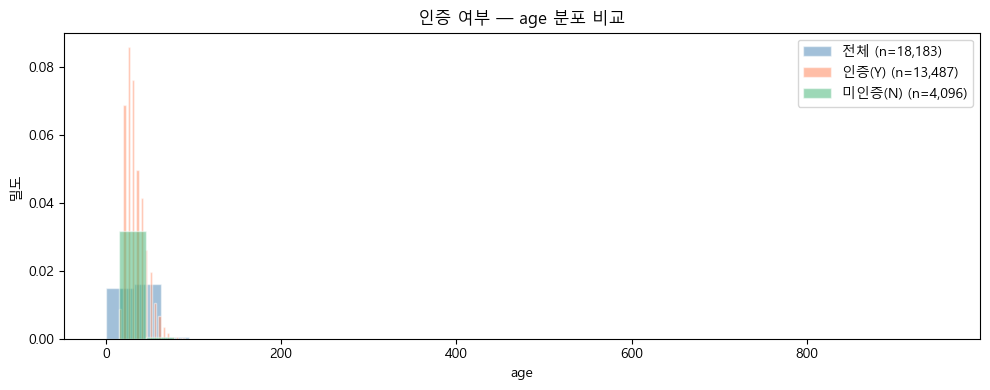

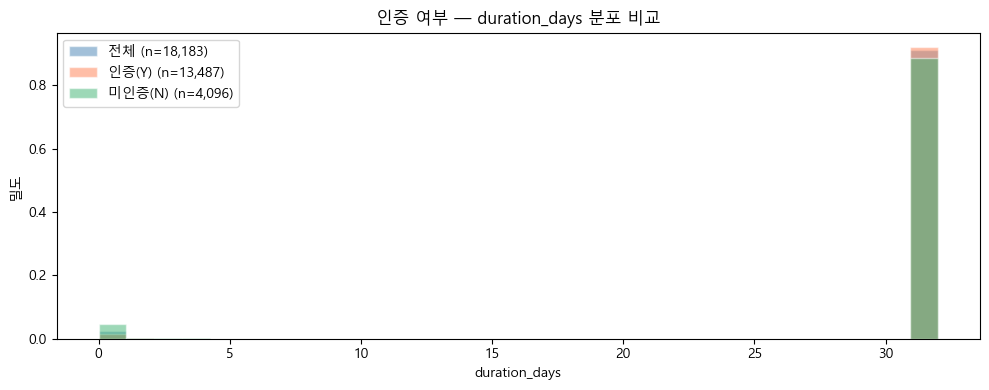

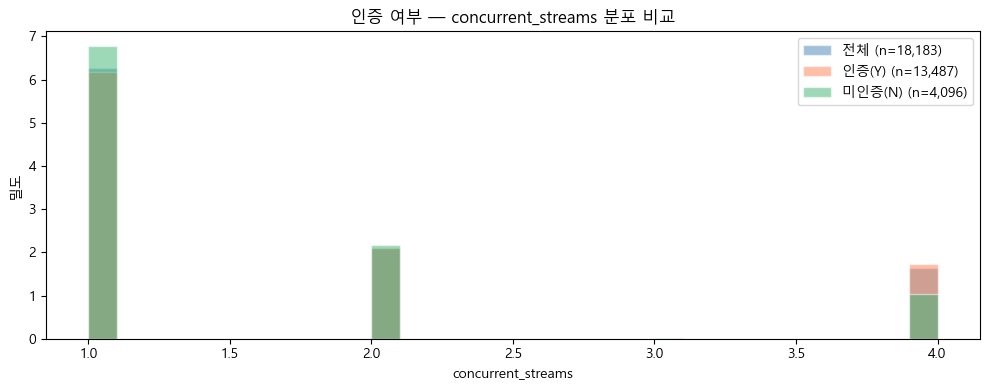

In [28]:
# 수치형 분포 비교
for col in ['amount', 'age', 'duration_days', 'concurrent_streams']:
    plot_segment_dist(seg_verified, col, '인증 여부')

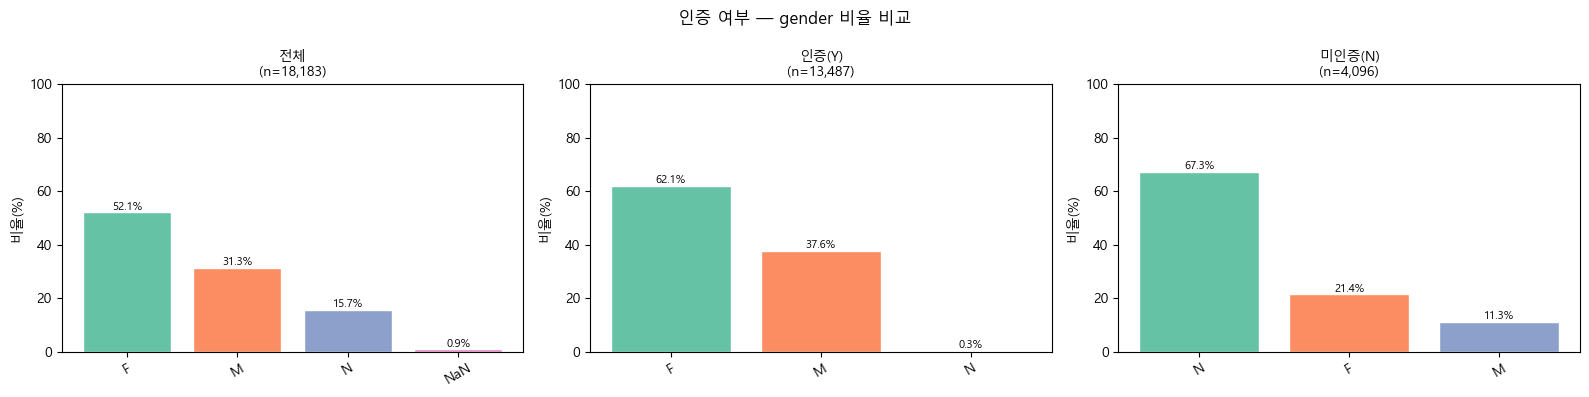

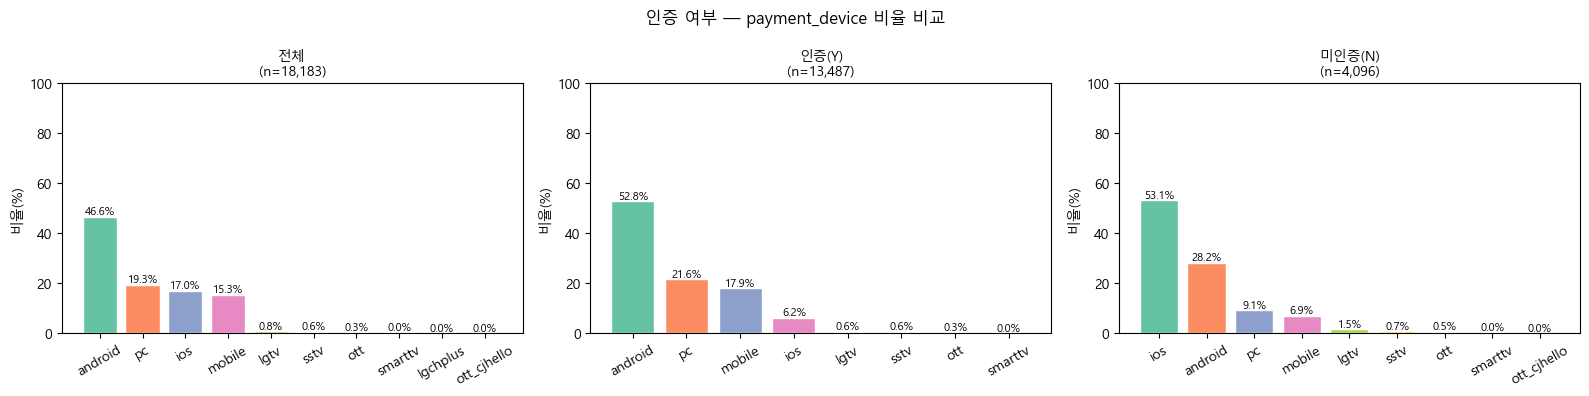

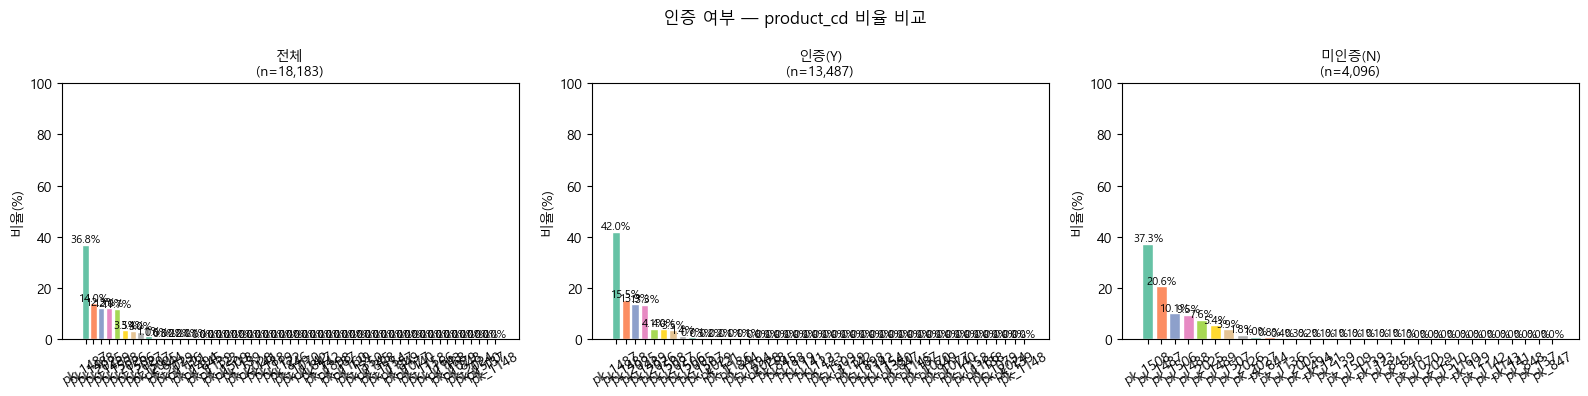

In [29]:
# 범주형 비교
for col in ['gender', 'payment_device', 'product_cd']:
    plot_segment_bar(seg_verified, col, '인증 여부')

In [30]:
# 미인증 고객의 age/gender 신뢰도 확인
unverified = mem[mem['is_user_verified'] == 'N']
print('미인증 고객 age 분포:')
print(unverified['age'].value_counts(dropna=False).head(10))
print(f'\n미인증 고객 중 age==0 비율: {(unverified["age"]==0).mean()*100:.1f}%')
print(f'미인증 고객 중 age>=100 비율: {(unverified["age"]>=100).mean()*100:.1f}%')

미인증 고객 age 분포:
age
40.0    3621
30.0     111
25.0     108
35.0      73
20.0      57
45.0      56
50.0      37
55.0      11
15.0       7
60.0       6
Name: count, dtype: int64

미인증 고객 중 age==0 비율: 0.0%
미인증 고객 중 age>=100 비율: 0.0%


### 7-2. 프로모션 참여 여부 세그먼트 (전체 / 참여 / 미참여)

> `promotion_yn`: O=100원 프로모션 참여, NaN=미참여  
> 프로모션 참여자는 첫 달 100원 → amount 분포에 강한 영향

In [31]:
seg_promo = {
    '전체':       mem,
    '프로모션 참여(O)':  mem[mem['promotion_yn'] == 'O'],
    '미참여(NaN)': mem[mem['promotion_yn'].isna()],
}

print('=== 세그먼트별 기본 현황 ===')
for label, df in seg_promo.items():
    print(f'{label:15s}: {len(df):,}명  ({len(df)/len(mem)*100:.1f}%)')

for label, df in seg_promo.items():
    segment_stats(df, label)

=== 세그먼트별 기본 현황 ===
전체             : 18,183명  (100.0%)
프로모션 참여(O)     : 9,203명  (50.6%)
미참여(NaN)       : 8,980명  (49.4%)

[전체] n=18,183명


,amount,age,concurrent_streams,duration_days
count,18183.00,18019.00,18113.00,18183.00
mean,3032.77,33.92,1.70,30.31
std,4456.24,12.61,1.09,5.05
min,7.69,0.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,35.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,16400.00,950.00,4.00,32.00



[프로모션 참여(O)] n=9,203명


,amount,age,concurrent_streams,duration_days
count,9203.0,9096.00,9203.00,9203.00
mean,100.0,32.12,1.85,30.73
std,0.0,11.61,1.22,2.82
min,100.0,15.00,1.00,0.00
25%,100.0,25.00,1.00,31.00
50%,100.0,30.00,1.00,31.00
75%,100.0,40.00,2.00,31.00
max,100.0,90.00,4.00,31.00



[미참여(NaN)] n=8,980명


,amount,age,concurrent_streams,duration_days
count,8980.00,8923.00,8910.00,8980.00
mean,6038.38,35.76,1.54,29.88
std,4728.77,13.30,0.91,6.57
min,7.69,0.00,1.00,0.00
25%,13.49,30.00,1.00,31.00
50%,7900.00,40.00,1.00,31.00
75%,7900.00,40.00,2.00,32.00
max,16400.00,950.00,4.00,32.00


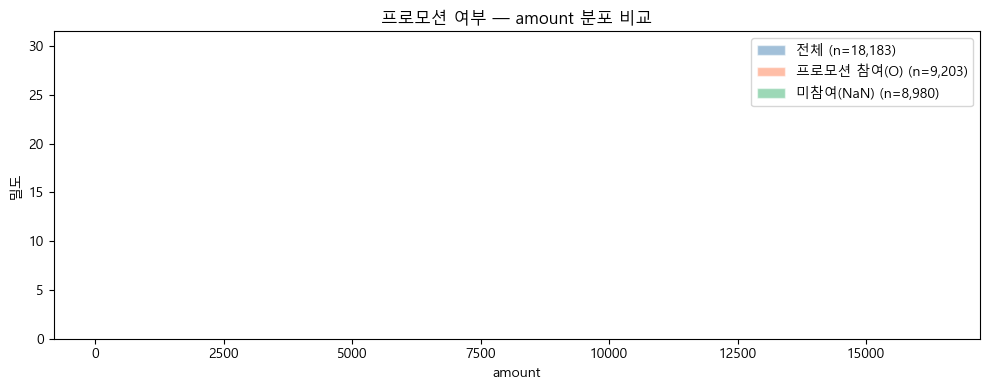

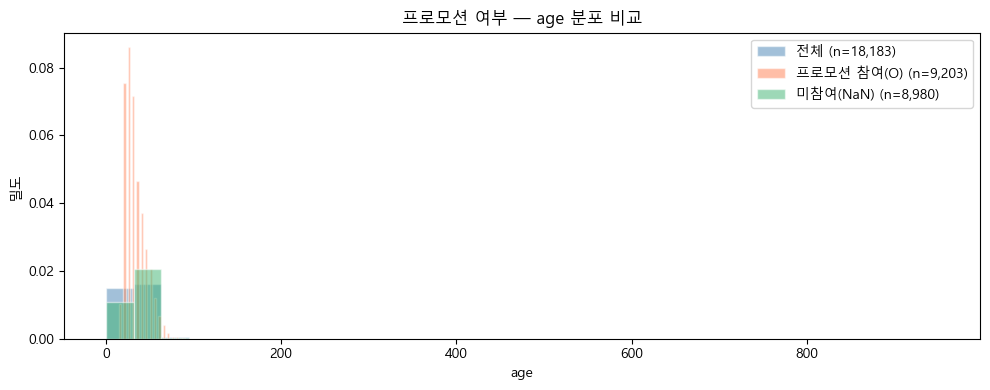

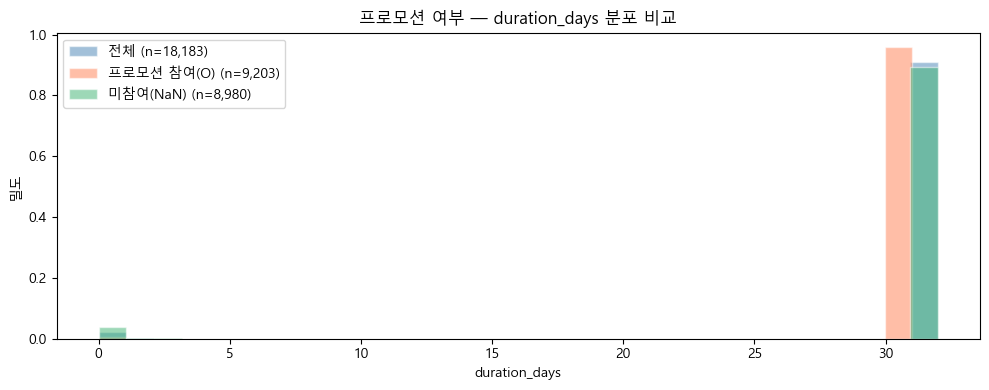

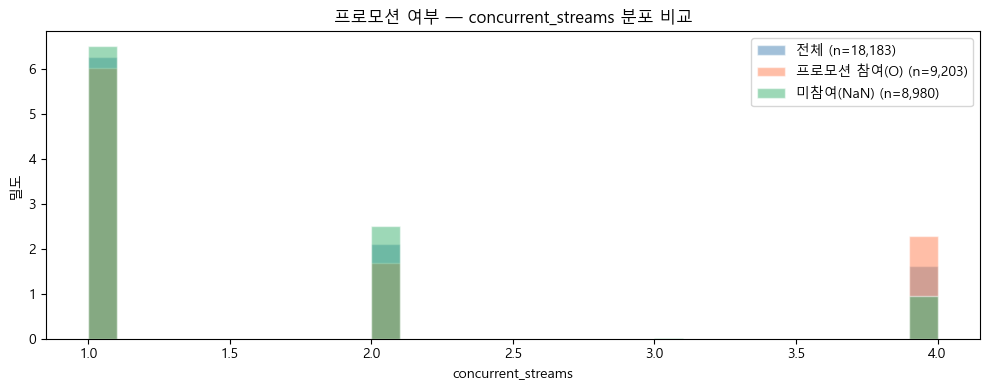

In [32]:
for col in ['amount', 'age', 'duration_days', 'concurrent_streams']:
    plot_segment_dist(seg_promo, col, '프로모션 여부')

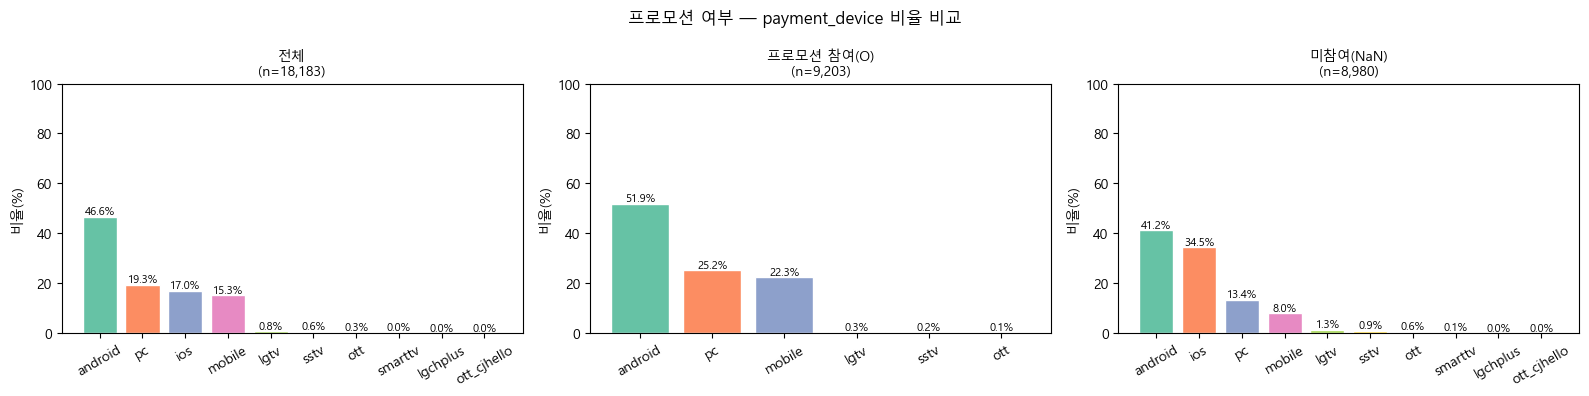

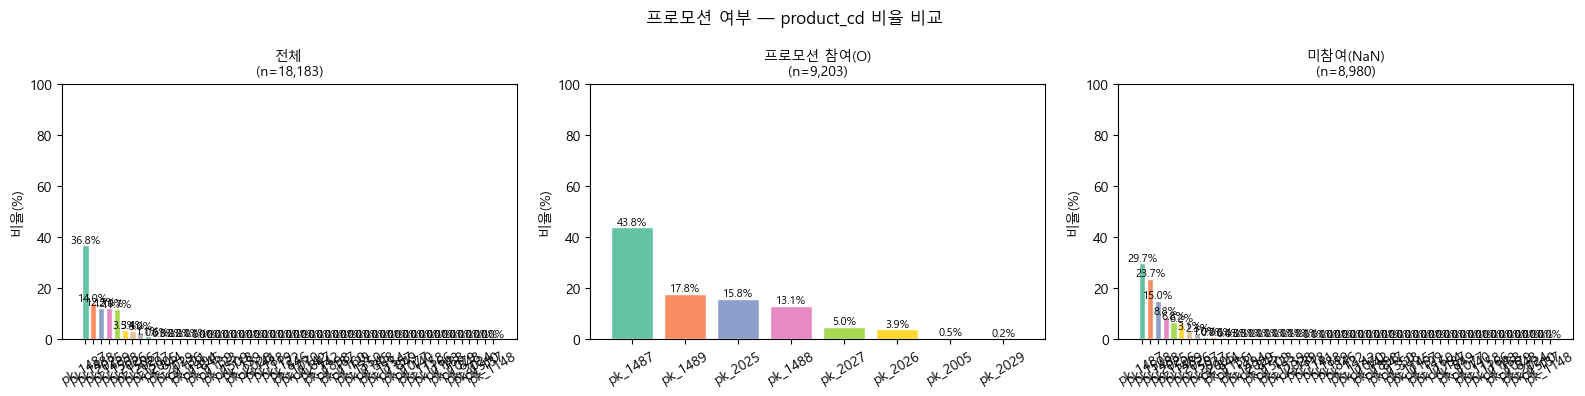

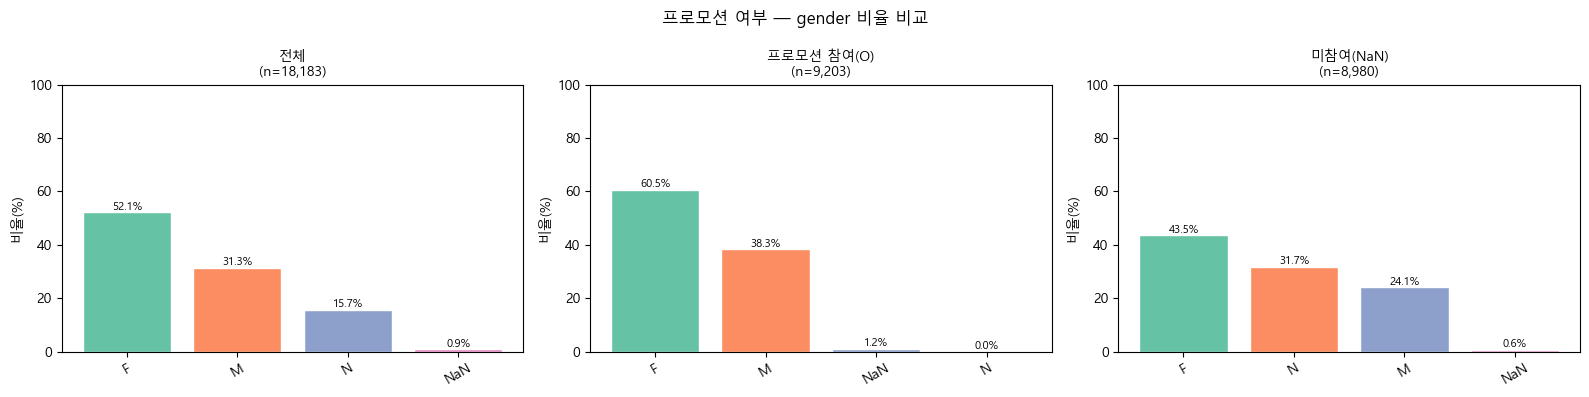

In [33]:
for col in ['payment_device', 'product_cd', 'gender']:
    plot_segment_bar(seg_promo, col, '프로모션 여부')

In [34]:
# 프로모션 참여 여부 × 재결제율
for label, df in seg_promo.items():
    rate = (df['repurchase'] == 'O').mean() * 100
    print(f'{label:15s} 재결제율: {rate:.1f}%')

전체              재결제율: 65.6%
프로모션 참여(O)      재결제율: 61.9%
미참여(NaN)        재결제율: 69.4%


### 7-3. 재결제 여부 세그먼트 (전체 / 재결제 / 미재결제)

> `repurchase`: O=재결제, NaN=미재결제 (= 이탈 후보)

In [35]:
seg_repurchase = {
    '전체':           mem,
    '재결제(O)':      mem[mem['repurchase'] == 'O'],
    '미재결제(NaN)':  mem[mem['repurchase'].isna()],
}

print('=== 세그먼트별 기본 현황 ===')
for label, df in seg_repurchase.items():
    print(f'{label:15s}: {len(df):,}명  ({len(df)/len(mem)*100:.1f}%)')

for label, df in seg_repurchase.items():
    segment_stats(df, label)

=== 세그먼트별 기본 현황 ===
전체             : 18,183명  (100.0%)
재결제(O)         : 11,931명  (65.6%)
미재결제(NaN)      : 6,252명  (34.4%)

[전체] n=18,183명


,amount,age,concurrent_streams,duration_days
count,18183.00,18019.00,18113.00,18183.00
mean,3032.77,33.92,1.70,30.31
std,4456.24,12.61,1.09,5.05
min,7.69,0.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,35.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,16400.00,950.00,4.00,32.00



[재결제(O)] n=11,931명


,amount,age,concurrent_streams,duration_days
count,11931.00,11924.00,11894.00,11931.00
mean,3424.58,34.54,1.64,31.12
std,4650.69,13.35,1.02,1.23
min,7.69,0.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,35.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,16400.00,950.00,4.00,32.00



[미재결제(NaN)] n=6,252명


,amount,age,concurrent_streams,duration_days
count,6252.00,6095.00,6219.00,6252.00
mean,2285.07,32.72,1.81,28.77
std,3953.42,10.91,1.20,8.23
min,9.89,0.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,30.00,1.00,31.00
75%,3950.00,40.00,2.00,31.00
max,13900.00,120.00,4.00,32.00


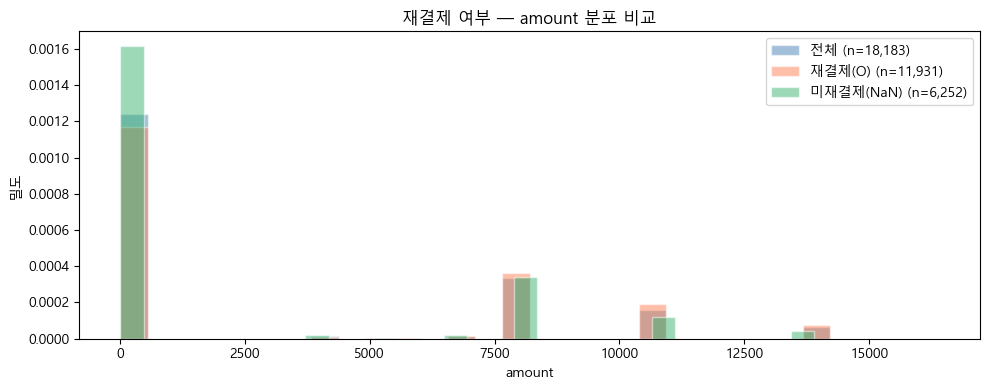

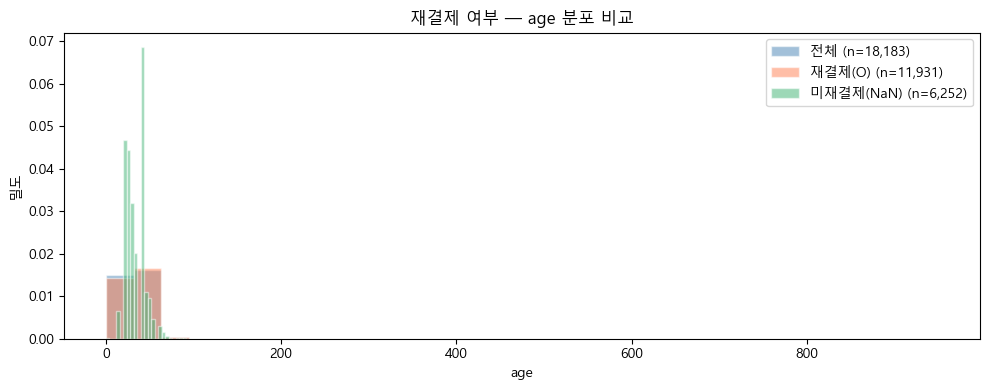

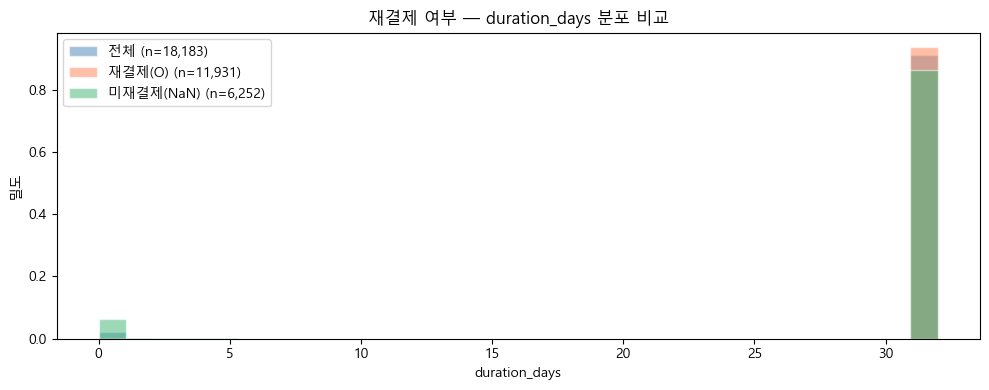

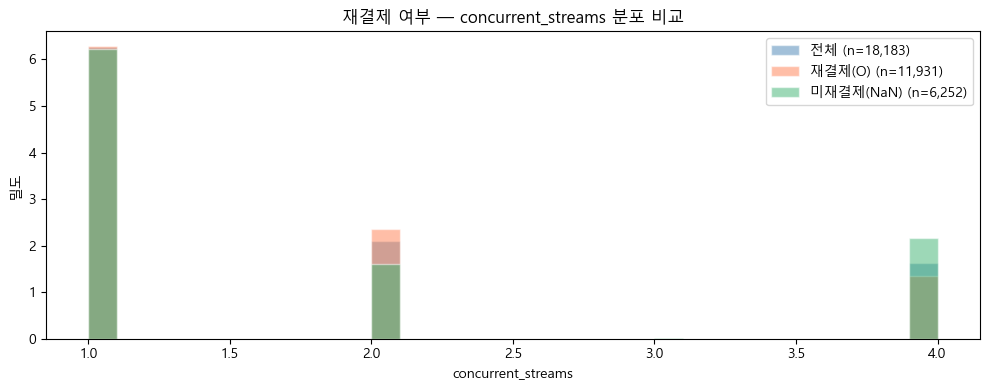

In [36]:
for col in ['amount', 'age', 'duration_days', 'concurrent_streams']:
    plot_segment_dist(seg_repurchase, col, '재결제 여부')

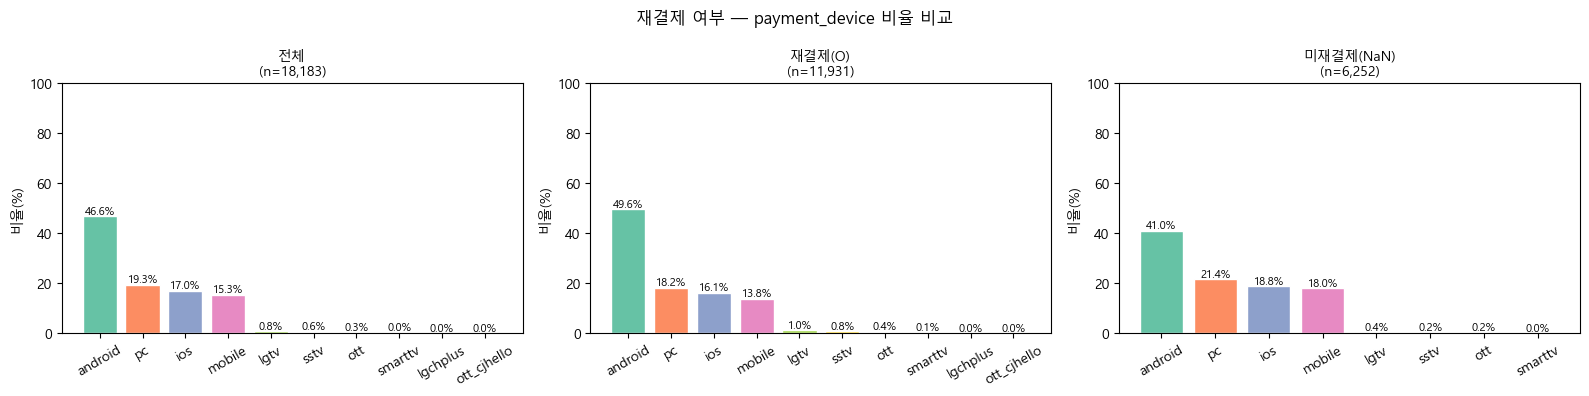

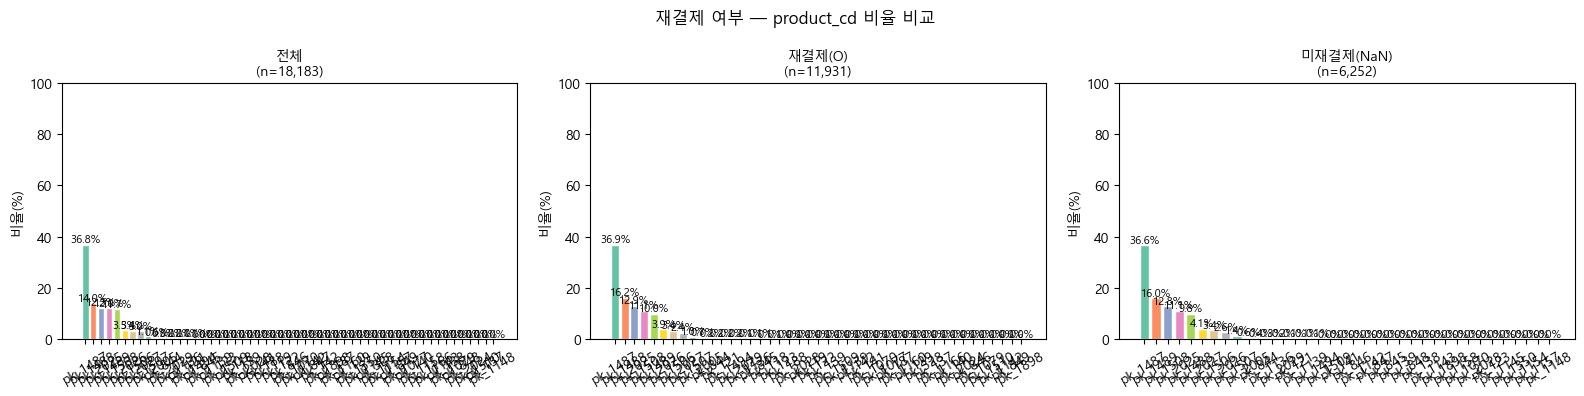

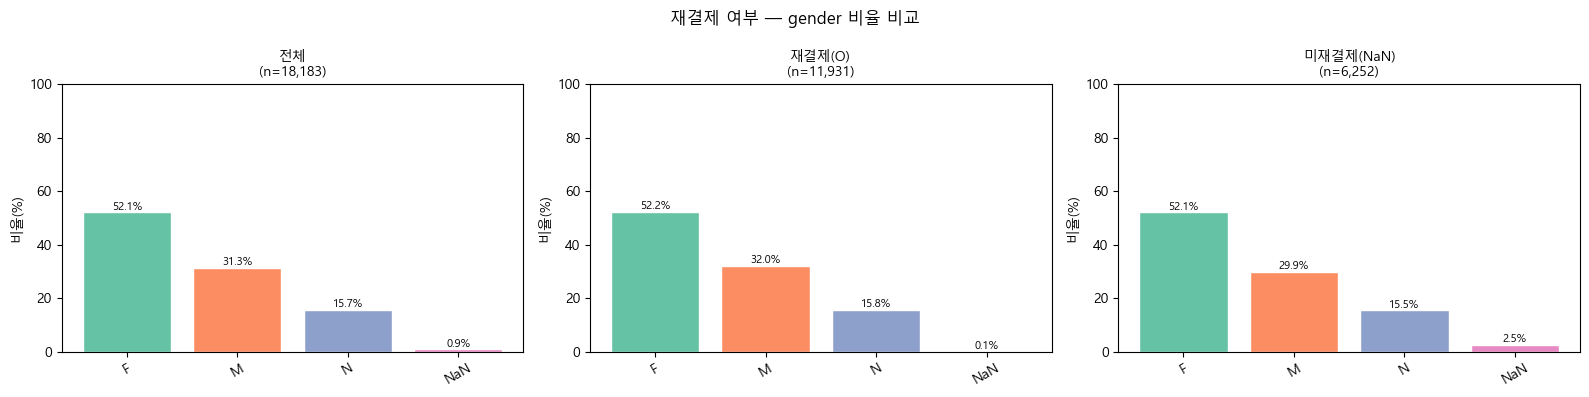

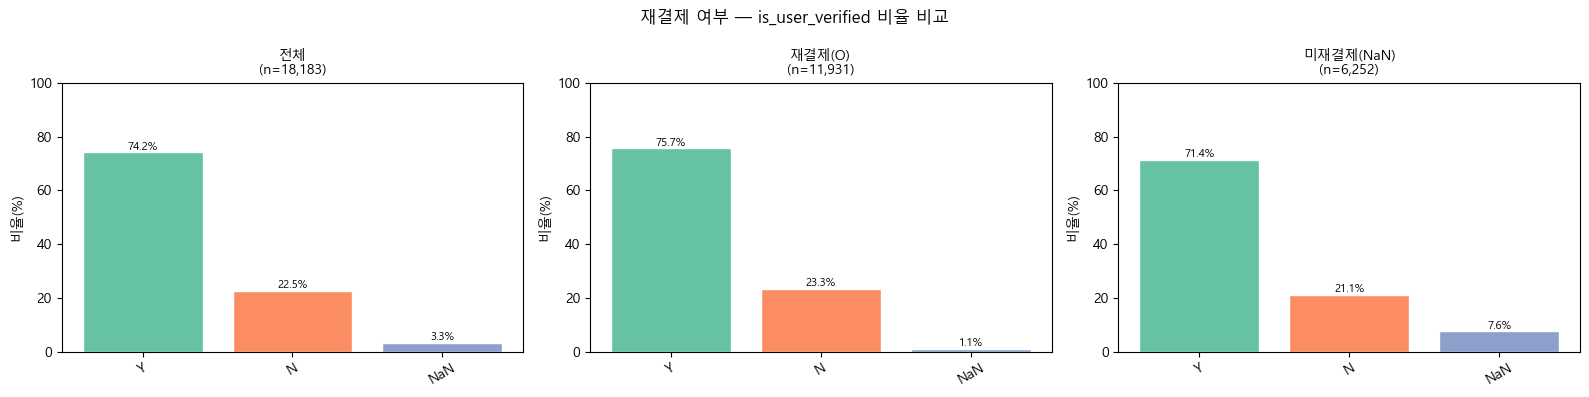

In [37]:
for col in ['payment_device', 'product_cd', 'gender', 'is_user_verified']:
    plot_segment_bar(seg_repurchase, col, '재결제 여부')

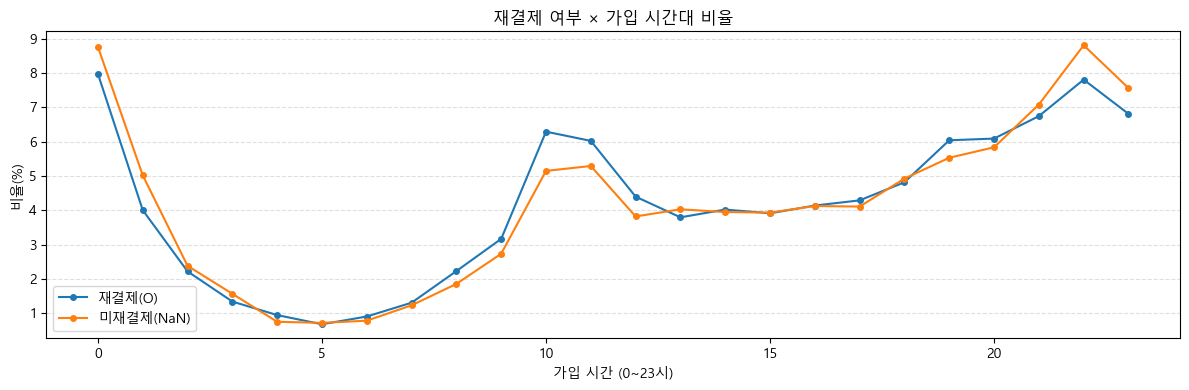

In [38]:
# 재결제 여부 × 가입 시간대
fig, ax = plt.subplots(figsize=(12, 4))
colors = {'재결제(O)': 'steelblue', '미재결제(NaN)': 'coral'}
for label, df in list(seg_repurchase.items())[1:]:
    hc = df['reg_hour'].value_counts().sort_index()
    ax.plot(hc.index, hc.values / len(df) * 100,
            marker='o', markersize=4, label=label, linewidth=1.5)
ax.set_title('재결제 여부 × 가입 시간대 비율', fontsize=12)
ax.set_xlabel('가입 시간 (0~23시)')
ax.set_ylabel('비율(%)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 7-4. 해지방어 여부 세그먼트 (전체 / 해지방어 / 비해당)

> `is_churn_prevented`: O=해지 신청 후 포인트 증정으로 철회, NaN=해지방어 미해당  
> 해지방어 고객은 **한 번 이탈 의사를 표시한 고객** — 재결제율/행동 패턴이 다를 수 있음

In [39]:
seg_churn = {
    '전체':           mem,
    '해지방어(O)':    mem[mem['is_churn_prevented'] == 'O'],
    '비해당(NaN)':    mem[mem['is_churn_prevented'].isna()],
}

print('=== 세그먼트별 기본 현황 ===')
for label, df in seg_churn.items():
    print(f'{label:15s}: {len(df):,}명  ({len(df)/len(mem)*100:.1f}%)')

for label, df in seg_churn.items():
    segment_stats(df, label)

=== 세그먼트별 기본 현황 ===
전체             : 18,183명  (100.0%)
해지방어(O)        : 3,257명  (17.9%)
비해당(NaN)       : 14,926명  (82.1%)

[전체] n=18,183명


,amount,age,concurrent_streams,duration_days
count,18183.00,18019.00,18113.00,18183.00
mean,3032.77,33.92,1.70,30.31
std,4456.24,12.61,1.09,5.05
min,7.69,0.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,35.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,16400.00,950.00,4.00,32.00



[해지방어(O)] n=3,257명


,amount,age,concurrent_streams,duration_days
count,3257.00,3235.00,3256.00,3257.00
mean,4840.64,32.77,1.70,30.16
std,4766.03,10.83,1.07,5.01
min,9.89,15.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,6950.00,30.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,13900.00,90.00,4.00,32.00



[비해당(NaN)] n=14,926명


,amount,age,concurrent_streams,duration_days
count,14926.00,14784.00,14857.00,14926.00
mean,2638.28,34.18,1.70,30.34
std,4285.71,12.95,1.09,5.06
min,7.69,0.00,1.00,0.00
25%,100.00,25.00,1.00,31.00
50%,100.00,35.00,1.00,31.00
75%,7900.00,40.00,2.00,31.00
max,16400.00,950.00,4.00,32.00


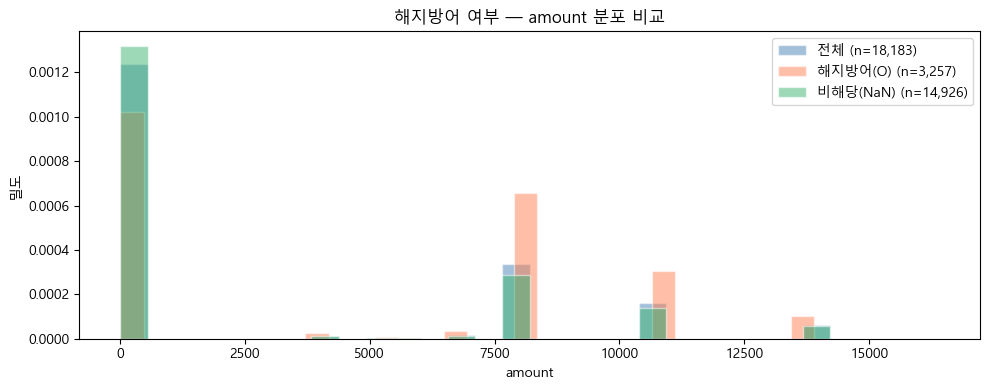

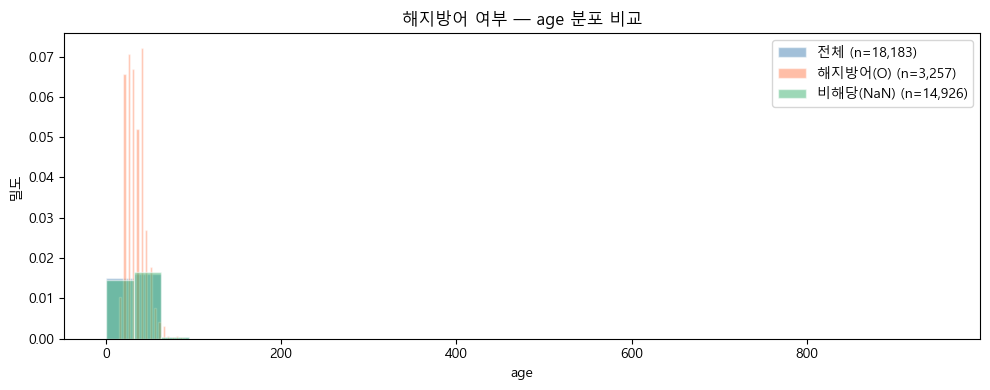

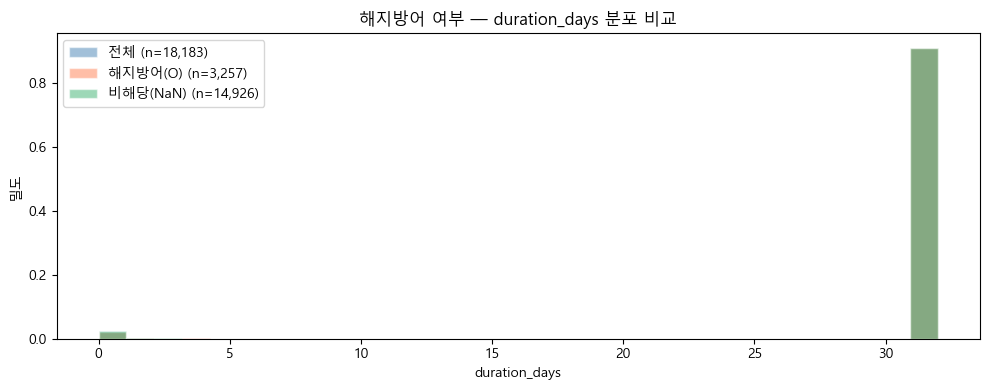

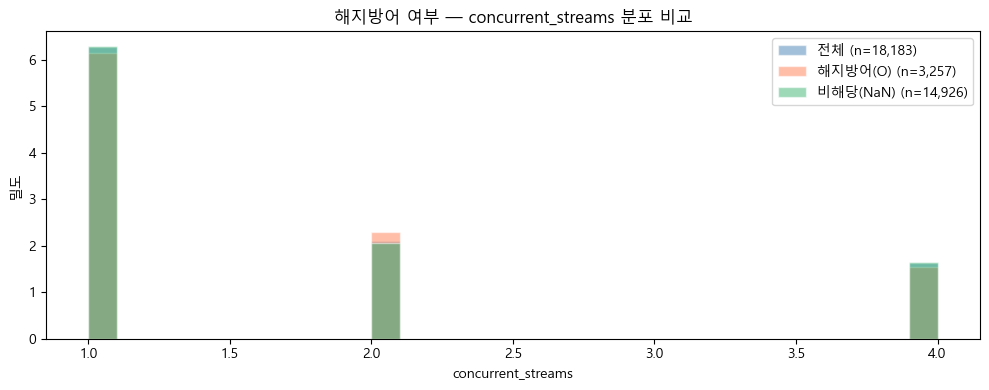

In [40]:
for col in ['amount', 'age', 'duration_days', 'concurrent_streams']:
    plot_segment_dist(seg_churn, col, '해지방어 여부')

In [41]:
# 해지방어 고객의 최종 재결제율 — 핵심 지표
for label, df in seg_churn.items():
    rate = (df['repurchase'] == 'O').mean() * 100
    n = len(df)
    print(f'{label:15s} 재결제율: {rate:.1f}%  (n={n:,})')

전체              재결제율: 65.6%  (n=18,183)
해지방어(O)         재결제율: 71.0%  (n=3,257)
비해당(NaN)        재결제율: 64.4%  (n=14,926)


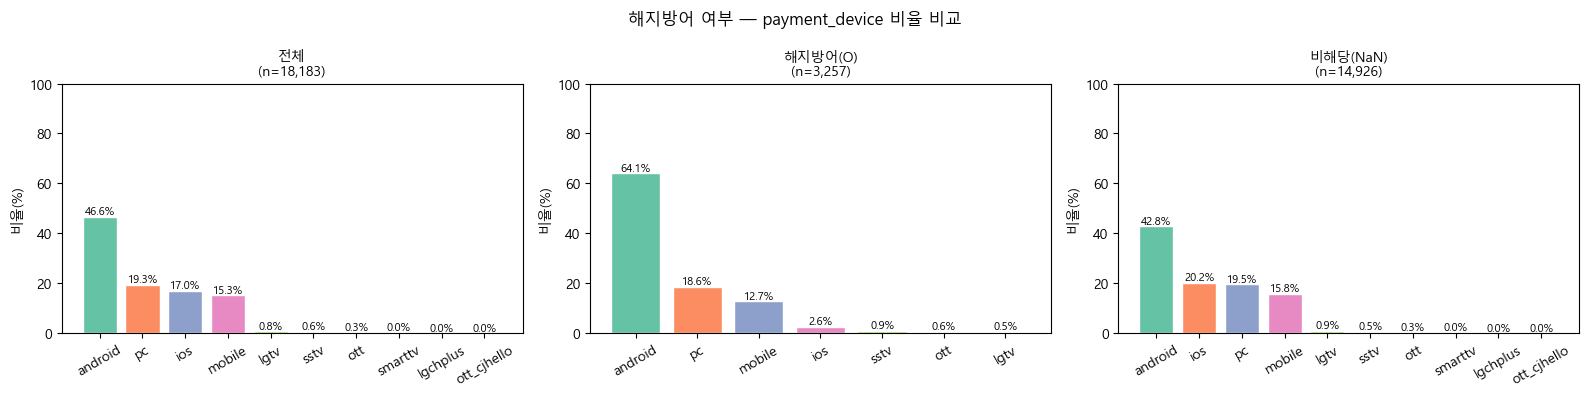

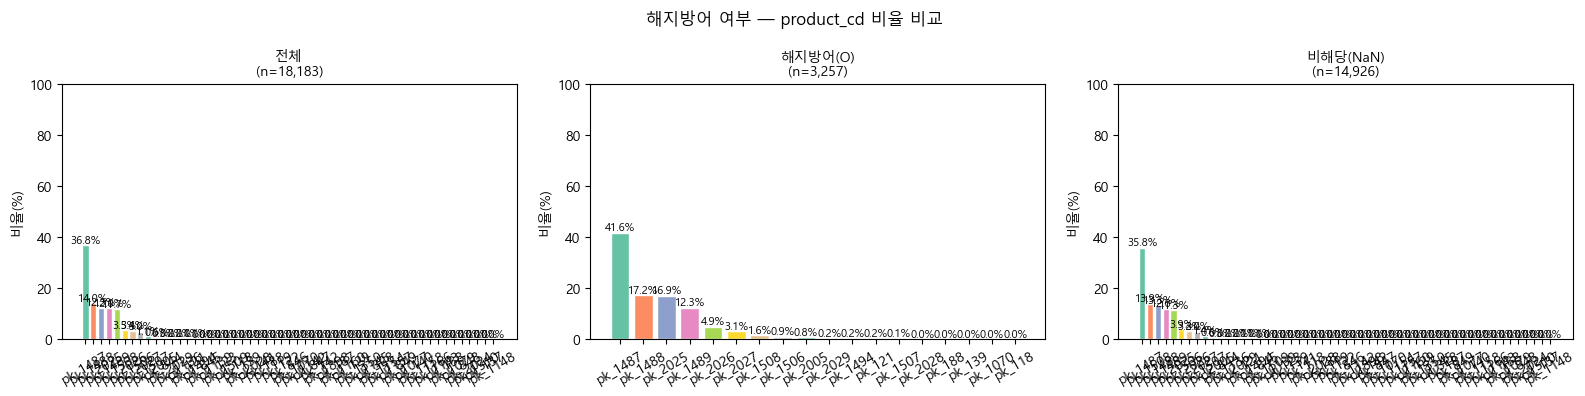

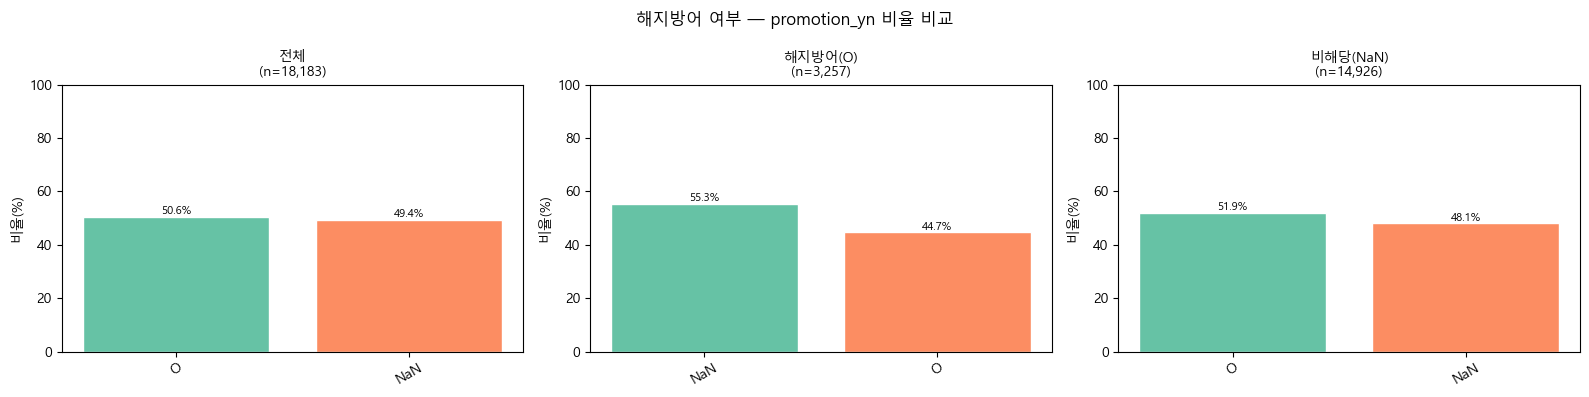

In [42]:
for col in ['payment_device', 'product_cd', 'promotion_yn']:
    plot_segment_bar(seg_churn, col, '해지방어 여부')

## 8. 교차 분석

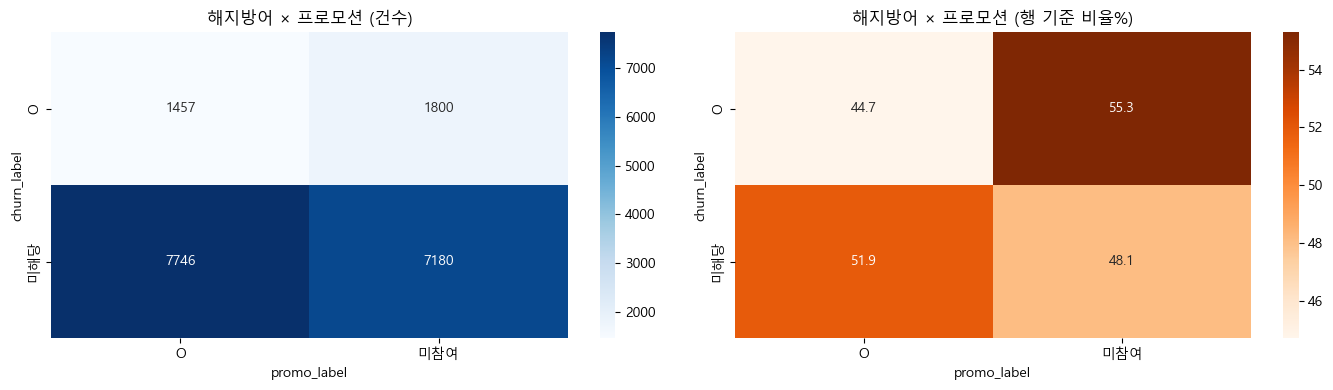

promo_label     O   미참여    All
churn_label                   
O            1457  1800   3257
미해당          7746  7180  14926
All          9203  8980  18183


In [43]:
# is_churn_prevented × promotion_yn
mem['churn_label']  = mem['is_churn_prevented'].fillna('미해당')
mem['promo_label']  = mem['promotion_yn'].fillna('미참여')

ct = pd.crosstab(mem['churn_label'], mem['promo_label'], margins=True)
ct_pct = pd.crosstab(mem['churn_label'], mem['promo_label'], normalize='index').round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(ct.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('해지방어 × 프로모션 (건수)', fontsize=12)

sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1])
axes[1].set_title('해지방어 × 프로모션 (행 기준 비율%)', fontsize=12)

plt.tight_layout()
plt.show()

print(ct)

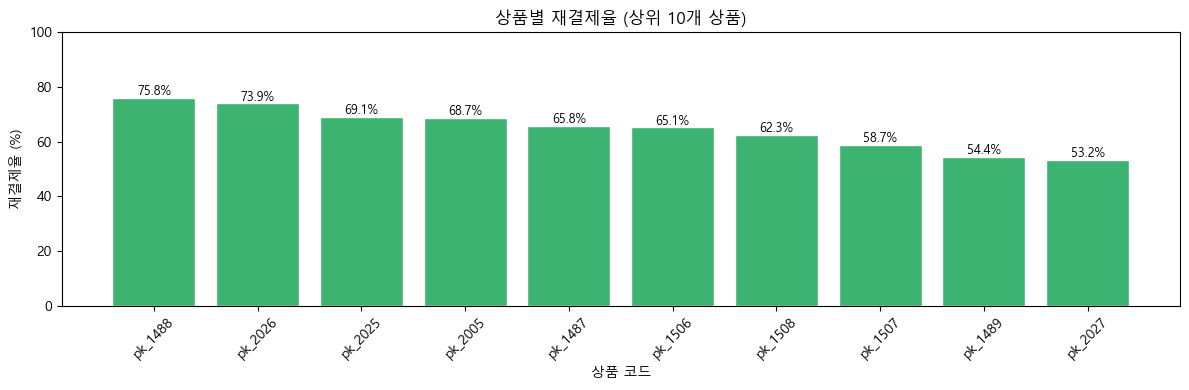

In [44]:
# 상품별 재결제율 (상위 10개 상품)
top10_prod = mem['product_cd'].value_counts().head(10).index
prod_repur = mem[mem['product_cd'].isin(top10_prod)].groupby('product_cd').apply(
    lambda x: (x['repurchase'] == 'O').mean() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(prod_repur.index, prod_repur.values, color='mediumseagreen', edgecolor='white')
ax.set_title('상품별 재결제율 (상위 10개 상품)', fontsize=12)
ax.set_xlabel('상품 코드')
ax.set_ylabel('재결제율 (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=45)
for bar, v in zip(bars, prod_repur.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

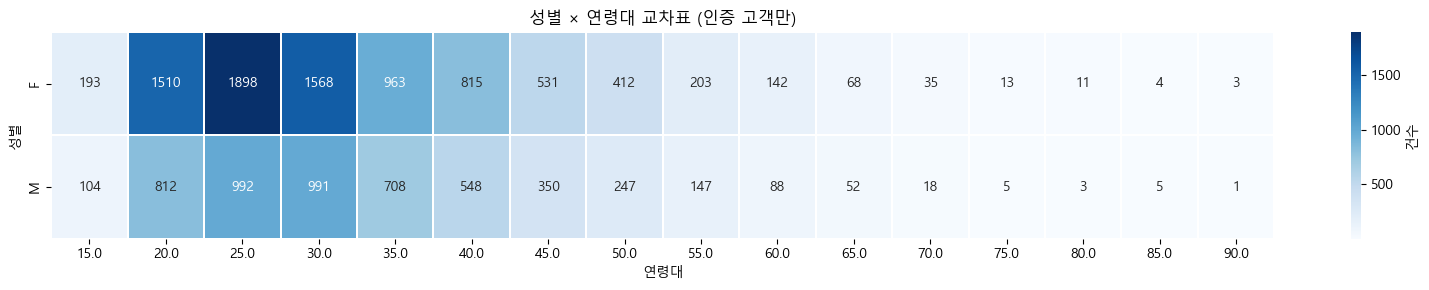

In [45]:
# 성별 × 연령대 히트맵 (인증 고객만)
verified = mem[(mem['is_user_verified'] == 'Y') & mem['gender'].isin(['F', 'M'])]
ga = verified.groupby(['gender', 'age']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 3))
sns.heatmap(ga, annot=True, fmt='d', cmap='Blues', linewidths=0.3,
            ax=ax, cbar_kws={'label': '건수'})
ax.set_title('성별 × 연령대 교차표 (인증 고객만)', fontsize=12)
ax.set_xlabel('연령대')
ax.set_ylabel('성별')
plt.tight_layout()
plt.show()

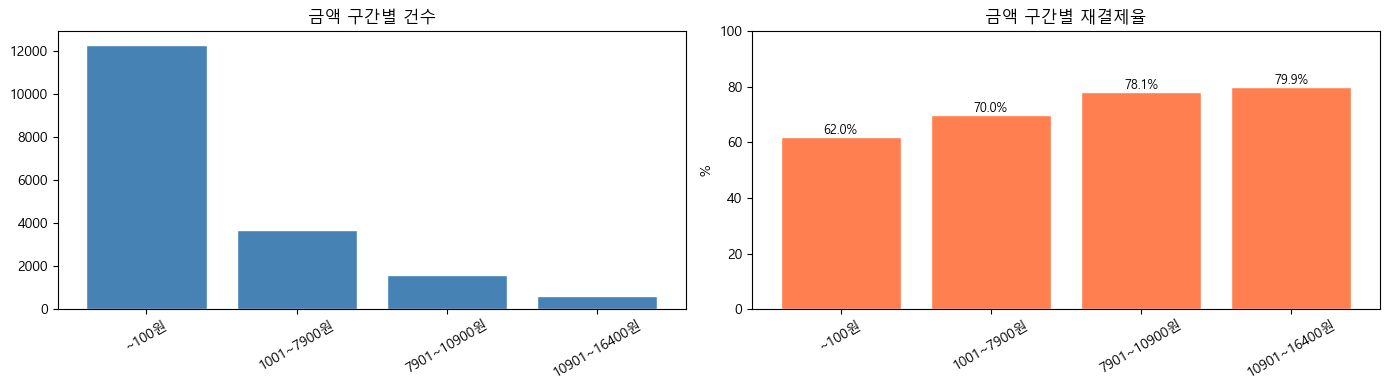

                   건수  재결제율(%)
amount_bin                    
~100원         12297.0    61.97
1001~7900원     3673.0    70.00
7901~10900원    1585.0    78.11
10901~16400원    628.0    79.94


In [46]:
# 금액 구간 × 재결제율
bins = [0, 100, 1000, 7900, 10900, 16400]
labels = ['~100원', '101~1000원', '1001~7900원', '7901~10900원', '10901~16400원']
mem['amount_bin'] = pd.cut(mem['amount'], bins=bins, labels=labels, right=True)

amt_repur = mem.groupby('amount_bin', observed=True).apply(
    lambda x: pd.Series({
        '건수': len(x),
        '재결제율(%)': (x['repurchase'] == 'O').mean() * 100
    })
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(amt_repur.index, amt_repur['건수'], color='steelblue', edgecolor='white')
axes[0].set_title('금액 구간별 건수', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(amt_repur.index, amt_repur['재결제율(%)'], color='coral', edgecolor='white')
axes[1].set_title('금액 구간별 재결제율', fontsize=12)
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(amt_repur['재결제율(%)']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(amt_repur)

## 9. 상관관계 분석

> `billing_method`는 범주형이므로 제외

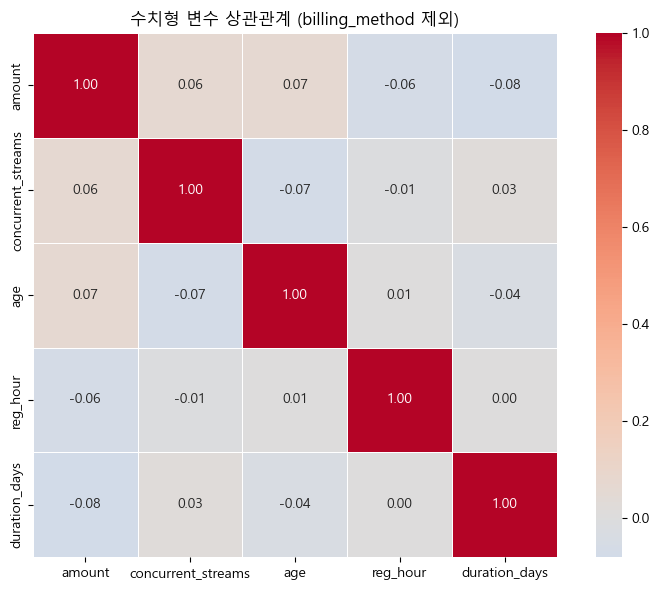


상관계수 절대값 기준 상위:
               변수1                변수2      상관계수
            amount      duration_days -0.080011
               age concurrent_streams -0.073327
               age             amount  0.065384
            amount concurrent_streams  0.064188
            amount           reg_hour -0.062751
               age      duration_days -0.035990
concurrent_streams      duration_days  0.025210
concurrent_streams           reg_hour -0.010072
               age           reg_hour  0.008068
     duration_days           reg_hour  0.004161


In [47]:
# billing_method 제외
num_for_corr = ['amount', 'concurrent_streams', 'age', 'reg_hour', 'duration_days']
corr = mem[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('수치형 변수 상관관계 (billing_method 제외)', fontsize=12)
plt.tight_layout()
plt.show()

# 상관계수 상위 쌍 출력
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['변수1', '변수2', '상관계수']
corr_pairs = corr_pairs[corr_pairs['변수1'] < corr_pairs['변수2']].sort_values(
    '상관계수', key=abs, ascending=False
)
print('\n상관계수 절대값 기준 상위:')
print(corr_pairs.to_string(index=False))

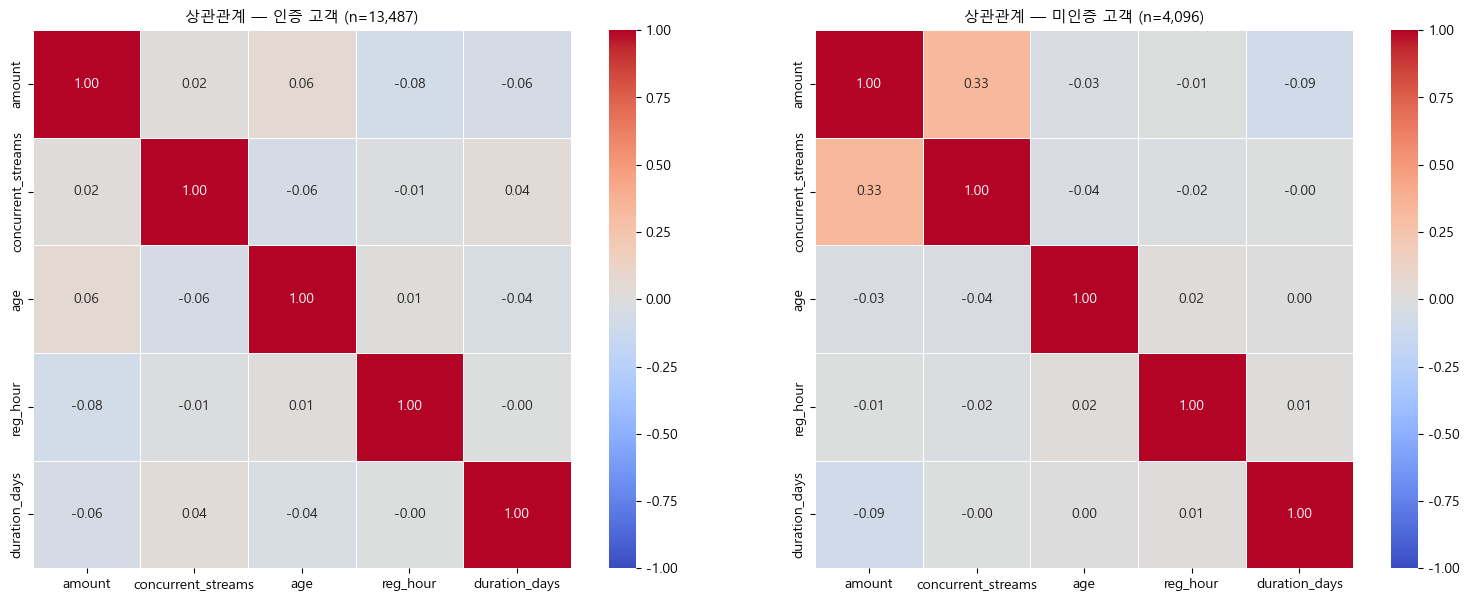

In [48]:
# 인증 / 미인증 고객별 상관관계 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, df) in zip(axes, [
    ('인증 고객', mem[mem['is_user_verified'] == 'Y']),
    ('미인증 고객', mem[mem['is_user_verified'] == 'N'])
]):
    corr_seg = df[num_for_corr].corr()
    sns.heatmap(corr_seg, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax, square=True, vmin=-1, vmax=1)
    ax.set_title(f'상관관계 — {label} (n={len(df):,})', fontsize=11)

plt.tight_layout()
plt.show()

## 10. User_Mapping — uid 중복 분석

> `uid` (해시값) 기준 중복 = **동일인이 탈퇴 후 재가입하여 USER_ID가 새로 발급된 케이스**  
> `USER_ID`는 항상 고유 — 완전 중복 행 없음


In [49]:
um = pd.read_csv(DATA_DIR + 'User_Mapping.csv')
uid_counts = um.groupby('uid')['USER_ID'].count()

print('=== User_Mapping 기본 현황 ===')
print(f'전체 행수     : {len(um):,}')
print(f'고유 uid      : {um["uid"].nunique():,}')
print(f'고유 USER_ID  : {um["USER_ID"].nunique():,}')
print(f'완전 중복 행  : {um.duplicated().sum()}')
print()
print('=== uid 1개당 USER_ID 개수 분포 ===')
cnt_dist = uid_counts.value_counts().sort_index()
for k, v in cnt_dist.items():
    print(f'  USER_ID {k}개: {v:,}명')
print()
print('=== 중복 uid 샘플 (USER_ID 2개 이상) ===')
dup_uids = uid_counts[uid_counts > 1].index
print(um[um['uid'].isin(dup_uids)].sort_values('uid').head(6).to_string(index=False))
print()
print('=== Membership 연결 현황 ===')
mem_uids = set(mem['user_no'])
dup_in_mem = set(dup_uids) & mem_uids
print(f'중복 uid {len(dup_uids)}개 중 Membership 존재: {len(dup_in_mem)}개')
print(f'중복 uid {len(dup_uids)}개 중 Membership 없음 (View_History only): {len(set(dup_uids) - mem_uids)}개')


=== User_Mapping 기본 현황 ===
전체 행수     : 19,877
고유 uid      : 19,828
고유 USER_ID  : 19,877
완전 중복 행  : 0

=== uid 1개당 USER_ID 개수 분포 ===
  USER_ID 1개: 19,780명
  USER_ID 2개: 47명
  USER_ID 3개: 1명

=== 중복 uid 샘플 (USER_ID 2개 이상) ===
                                                                                                                             uid  USER_ID
0258fd467c5765400d487d203f7c77afb597120daa9b1ede96e6a06122e89ea3120f1c5b6932ce435b954aab5da1999305ab7de84225bd741ee334c26ff1ce33    16255
0258fd467c5765400d487d203f7c77afb597120daa9b1ede96e6a06122e89ea3120f1c5b6932ce435b954aab5da1999305ab7de84225bd741ee334c26ff1ce33     3363
03207f956c0a2d363285286b1a9ede62e03373a9242253c7d6d5fb99819d4eb983fc1191e4dda5dd1b15ad690f9f115c47140236a4887ee22e1ab344985982d5     1503
03207f956c0a2d363285286b1a9ede62e03373a9242253c7d6d5fb99819d4eb983fc1191e4dda5dd1b15ad690f9f115c47140236a4887ee22e1ab344985982d5     5706
06413c96660e23ddd8e6cc93b3e03e299201a9a1aa05ba70ea10b8a8c6f7a17686772ce450d9427ac59dd2

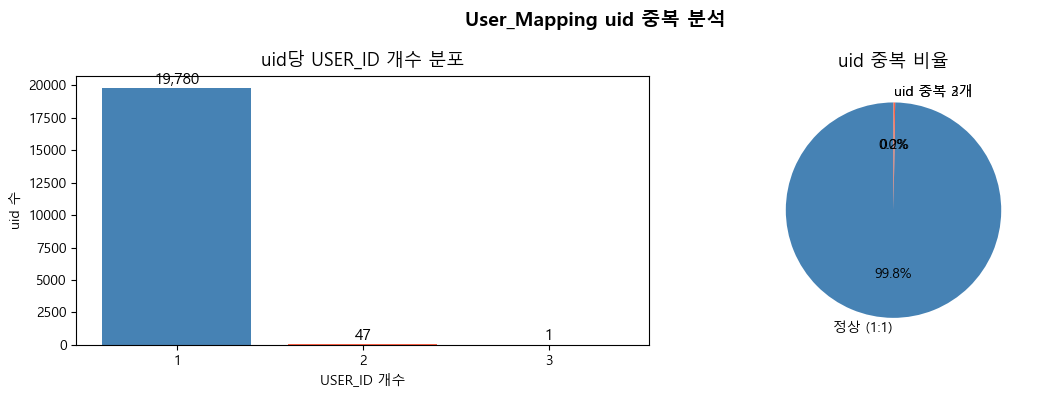

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cnt_dist = uid_counts.value_counts().sort_index()
bars = axes[0].bar(cnt_dist.index.astype(str), cnt_dist.values,
                   color=['steelblue', 'tomato', 'orange'])
axes[0].set_title('uid당 USER_ID 개수 분포', fontsize=13)
axes[0].set_xlabel('USER_ID 개수')
axes[0].set_ylabel('uid 수')
for bar, val in zip(bars, cnt_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)

labels_pie = ['정상 (1:1)', 'uid 중복 2개', 'uid 중복 3개']
sizes = [int(cnt_dist.get(1, 0)), int(cnt_dist.get(2, 0)), int(cnt_dist.get(3, 0))]
axes[1].pie(sizes, labels=labels_pie,
            colors=['steelblue', 'tomato', 'orange'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('uid 중복 비율', fontsize=13)

plt.suptitle('User_Mapping uid 중복 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. View_History EDA

> 컨럼: USER_ID, MOVIE_ID, DURATION(분), WATCH_DAY(YYYYMMDD), WATCH_SEQ  
> 시청 기간: 2021-03-01 ~ 2021-04-05 / 전체 106,205건


In [51]:
vh = pd.read_csv(DATA_DIR + 'View_History.csv')
vh['WATCH_DAY'] = pd.to_datetime(vh['WATCH_DAY'].astype(str), format='%Y%m%d')

print('=== 기본 현황 ===')
print(f'행 수       : {len(vh):,}')
print(f'고유 USER_ID : {vh["USER_ID"].nunique():,}')
print(f'고유 MOVIE_ID: {vh["MOVIE_ID"].nunique():,}')
print(f'시청 기간  : {vh["WATCH_DAY"].min().date()} ~ {vh["WATCH_DAY"].max().date()}')
print(f'결측치     : {vh.isnull().sum().sum()}')
print()
print('=== DURATION (시청 시간, 분) ===')
print(vh['DURATION'].describe().round(1).to_string())
cap_cnt = (vh['DURATION'] == 200).sum()
print(f'DURATION=200 (코값): {cap_cnt}건 ({cap_cnt/len(vh)*100:.1f}%)')
print()
print('=== WATCH_SEQ 분포 (1~5) ===')
print(vh['WATCH_SEQ'].value_counts().sort_index().head(5).to_string())


=== 기본 현황 ===
행 수       : 106,205
고유 USER_ID : 14,892
고유 MOVIE_ID: 5,196
시청 기간  : 2021-03-01 ~ 2021-04-05
결측치     : 0

=== DURATION (시청 시간, 분) ===
count    106205.0
mean         44.5
std          47.7
min           1.0
25%           2.0
50%          24.0
75%          86.0
max         200.0
DURATION=200 (코값): 644건 (0.6%)

=== WATCH_SEQ 분포 (1~5) ===
WATCH_SEQ
1    58127
2    25271
3    11081
4     5214
5     2603


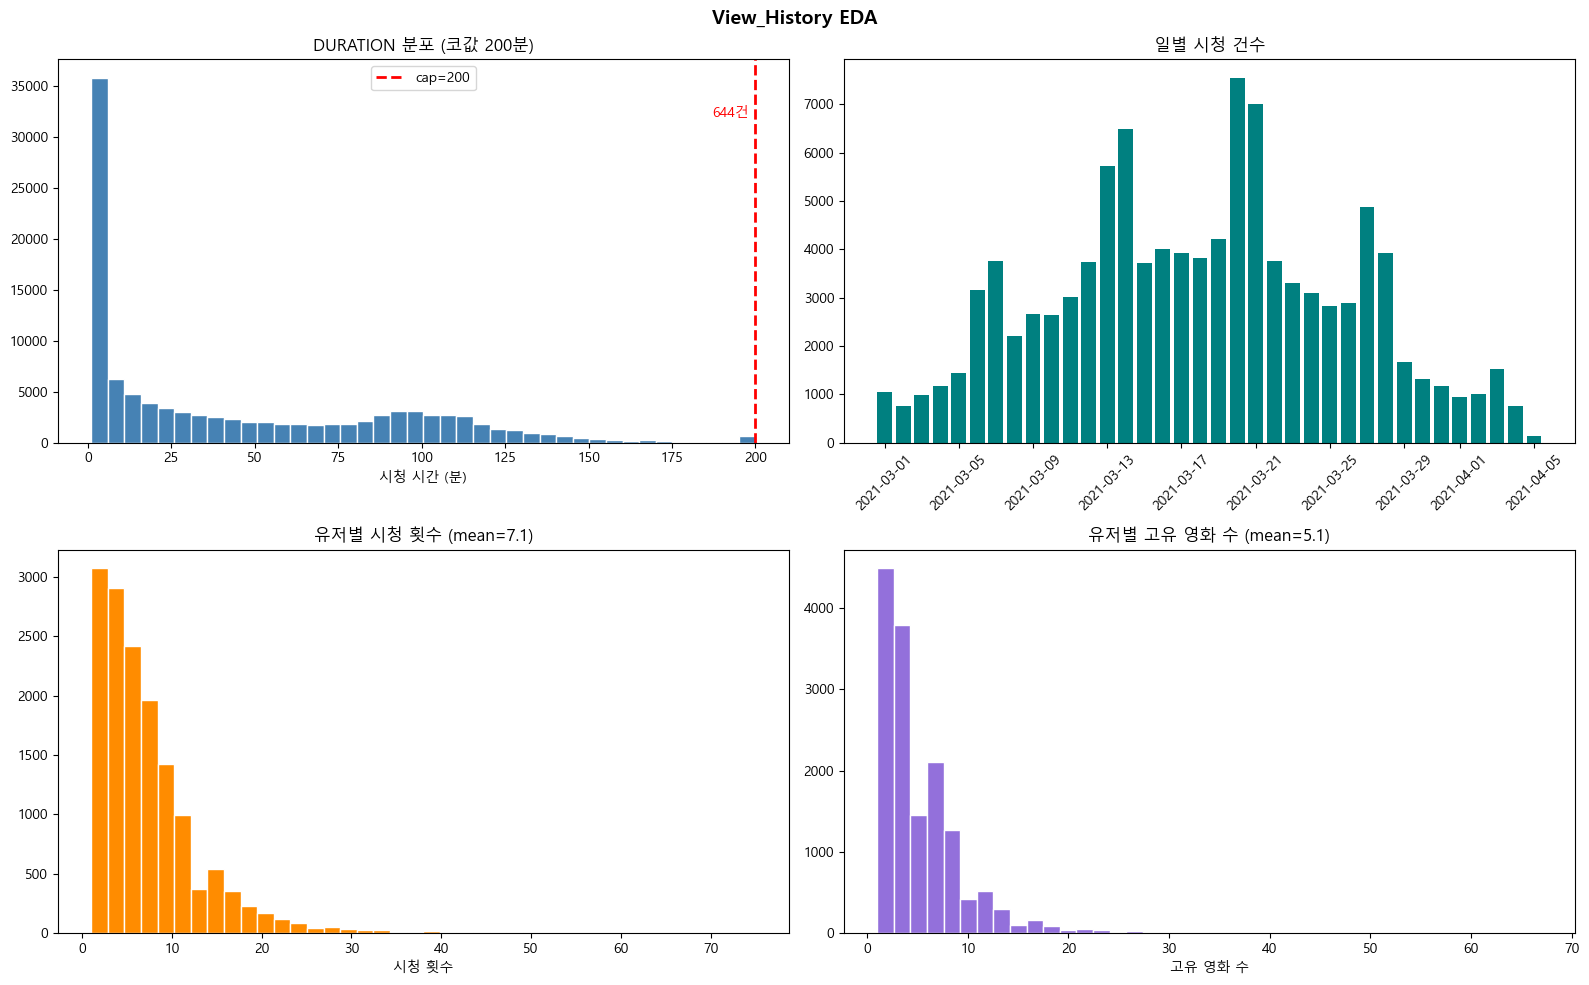

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(vh['DURATION'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].axvline(200, color='red', linestyle='--', linewidth=2, label='cap=200')
ymax = axes[0,0].get_ylim()[1]
axes[0,0].text(198, ymax*0.85, f'{cap_cnt}건', color='red', ha='right', fontsize=10)
axes[0,0].set_title('DURATION 분포 (코값 200분)', fontsize=12)
axes[0,0].set_xlabel('시청 시간 (분)')
axes[0,0].legend()

daily = vh.groupby('WATCH_DAY').size()
axes[0,1].bar(daily.index, daily.values, color='teal', width=0.8)
axes[0,1].set_title('일별 시청 건수', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45)

user_cnt = vh.groupby('USER_ID').size()
axes[1,0].hist(user_cnt, bins=40, color='darkorange', edgecolor='white')
axes[1,0].set_title(f'유저별 시청 횟수 (mean={user_cnt.mean():.1f})', fontsize=12)
axes[1,0].set_xlabel('시청 횟수')

user_movies = vh.groupby('USER_ID')['MOVIE_ID'].nunique()
axes[1,1].hist(user_movies, bins=40, color='mediumpurple', edgecolor='white')
axes[1,1].set_title(f'유저별 고유 영화 수 (mean={user_movies.mean():.1f})', fontsize=12)
axes[1,1].set_xlabel('고유 영화 수')

plt.suptitle('View_History EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [53]:
um = pd.read_csv(DATA_DIR + 'User_Mapping.csv')
vh_feat = vh.groupby('USER_ID').agg(
    total_watch_count    = ('MOVIE_ID', 'count'),
    total_watch_duration = ('DURATION', 'sum'),
    unique_movies        = ('MOVIE_ID', 'nunique'),
    avg_duration         = ('DURATION', 'mean'),
    watch_days           = ('WATCH_DAY', 'nunique'),
).reset_index()
vh_feat['has_watch'] = 1

merged = mem.merge(um, left_on='user_no', right_on='uid', how='left')
merged = merged.merge(vh_feat, on='USER_ID', how='left')
merged['has_watch'] = merged['has_watch'].fillna(0).astype(int)

print(f'Membership 전체: {len(merged):,}')
print(f'시청 이력 있는 유저: {merged["has_watch"].sum():,} ({merged["has_watch"].mean()*100:.1f}%)')
print(f'시청 이력 없는 유저: {(merged["has_watch"]==0).sum():,}')
print()
print('=== 시청 이력 유무별 재결제율 ===')
for has, grp in merged.groupby('has_watch'):
    rate = (grp['repurchase'] == 'O').mean() * 100
    label = '시청 있음' if has else '시청 없음'
    print(f'  {label}: {rate:.1f}% (n={len(grp):,})')
print()
print(merged[['total_watch_count','total_watch_duration','unique_movies','avg_duration','watch_days']].describe().round(1).to_string())


Membership 전체: 18,294
시청 이력 있는 유저: 15,233 (83.3%)
시청 이력 없는 유저: 3,061

=== 시청 이력 유무별 재결제율 ===
  시청 없음: 65.9% (n=3,061)
  시청 있음: 65.2% (n=15,233)

       total_watch_count  total_watch_duration  unique_movies  avg_duration  watch_days
count            15233.0               15233.0        15233.0       15233.0     15233.0
mean                 7.1                 317.4            5.1          44.9         3.9
std                  6.0                 328.0            4.3          30.5         2.6
min                  1.0                   1.0            1.0           1.0         1.0
25%                  3.0                  98.0            2.0          22.3         2.0
50%                  6.0                 225.0            4.0          41.7         3.0
75%                 10.0                 437.0            7.0          63.5         5.0
max                 75.0                4419.0           67.0         200.0        21.0


### 11-1. 시청 행동 세그먼트 비교

> 인증/미인증, 재결제/미재결제 교차로 시청 행동 차이 확인


In [54]:
# merged가 없으면 안전하게 다시 생성
if 'merged' not in dir():
    um = pd.read_csv(DATA_DIR + 'User_Mapping.csv')
    vh_feat = vh.groupby('USER_ID').agg(
        total_watch_count    = ('MOVIE_ID', 'count'),
        total_watch_duration = ('DURATION', 'sum'),
        unique_movies        = ('MOVIE_ID', 'nunique'),
        avg_duration         = ('DURATION', 'mean'),
        watch_days           = ('WATCH_DAY', 'nunique'),
    ).reset_index()
    vh_feat['has_watch'] = 1
    merged = mem.merge(um, left_on='user_no', right_on='uid', how='left')
    merged = merged.merge(vh_feat, on='USER_ID', how='left')
    merged['has_watch'] = merged['has_watch'].fillna(0).astype(int)

feat_cols = ['total_watch_count', 'total_watch_duration', 'unique_movies', 'avg_duration', 'watch_days']
feat_labels = ['시청횟수', '시청시간(분)', '고유영화', '평균시청(분)', '시청일수']

segs = [
    ('인증 여부', 'is_user_verified', [('Y', '인증(Y)'), ('N', '미인증(N)')]),
    ('재결제 여부', 'repurchase',       [('O', '재결제(O)'), (None, '미재결제')]),
]

for seg_name, col, groups in segs:
    print(f'=== {seg_name}x시청행동 평균 ===')
    rows = []
    for val, label in groups:
        if val is None:
            grp = merged[merged[col].isna()]
        else:
            grp = merged[merged[col] == val]
        watch_grp = grp[grp['has_watch'] == 1]
        row = {'': label, 'n': len(grp), '시청유무(%)': f"{grp['has_watch'].mean()*100:.1f}"}
        for fc, fl in zip(feat_cols, feat_labels):
            row[fl] = f"{watch_grp[fc].mean():.1f}" if len(watch_grp) > 0 else '-'
        rows.append(row)
    print(pd.DataFrame(rows).to_string(index=False))
    print()


=== 인증 여부x시청행동 평균 ===
           n 시청유무(%) 시청횟수 시청시간(분) 고유영화 평균시청(분) 시청일수
 인증(Y) 13548    83.4  7.2   320.6  5.1    45.0  3.9
미인증(N)  4141    82.6  7.1   311.4  5.0    44.3  3.9

=== 재결제 여부x시청행동 평균 ===
           n 시청유무(%) 시청횟수 시청시간(분) 고유영화 평균시청(분) 시청일수
재결제(O) 11955    83.1  7.1   316.3  5.1    45.0  3.9
  미재결제  6339    83.5  7.3   319.3  5.2    44.7  3.9



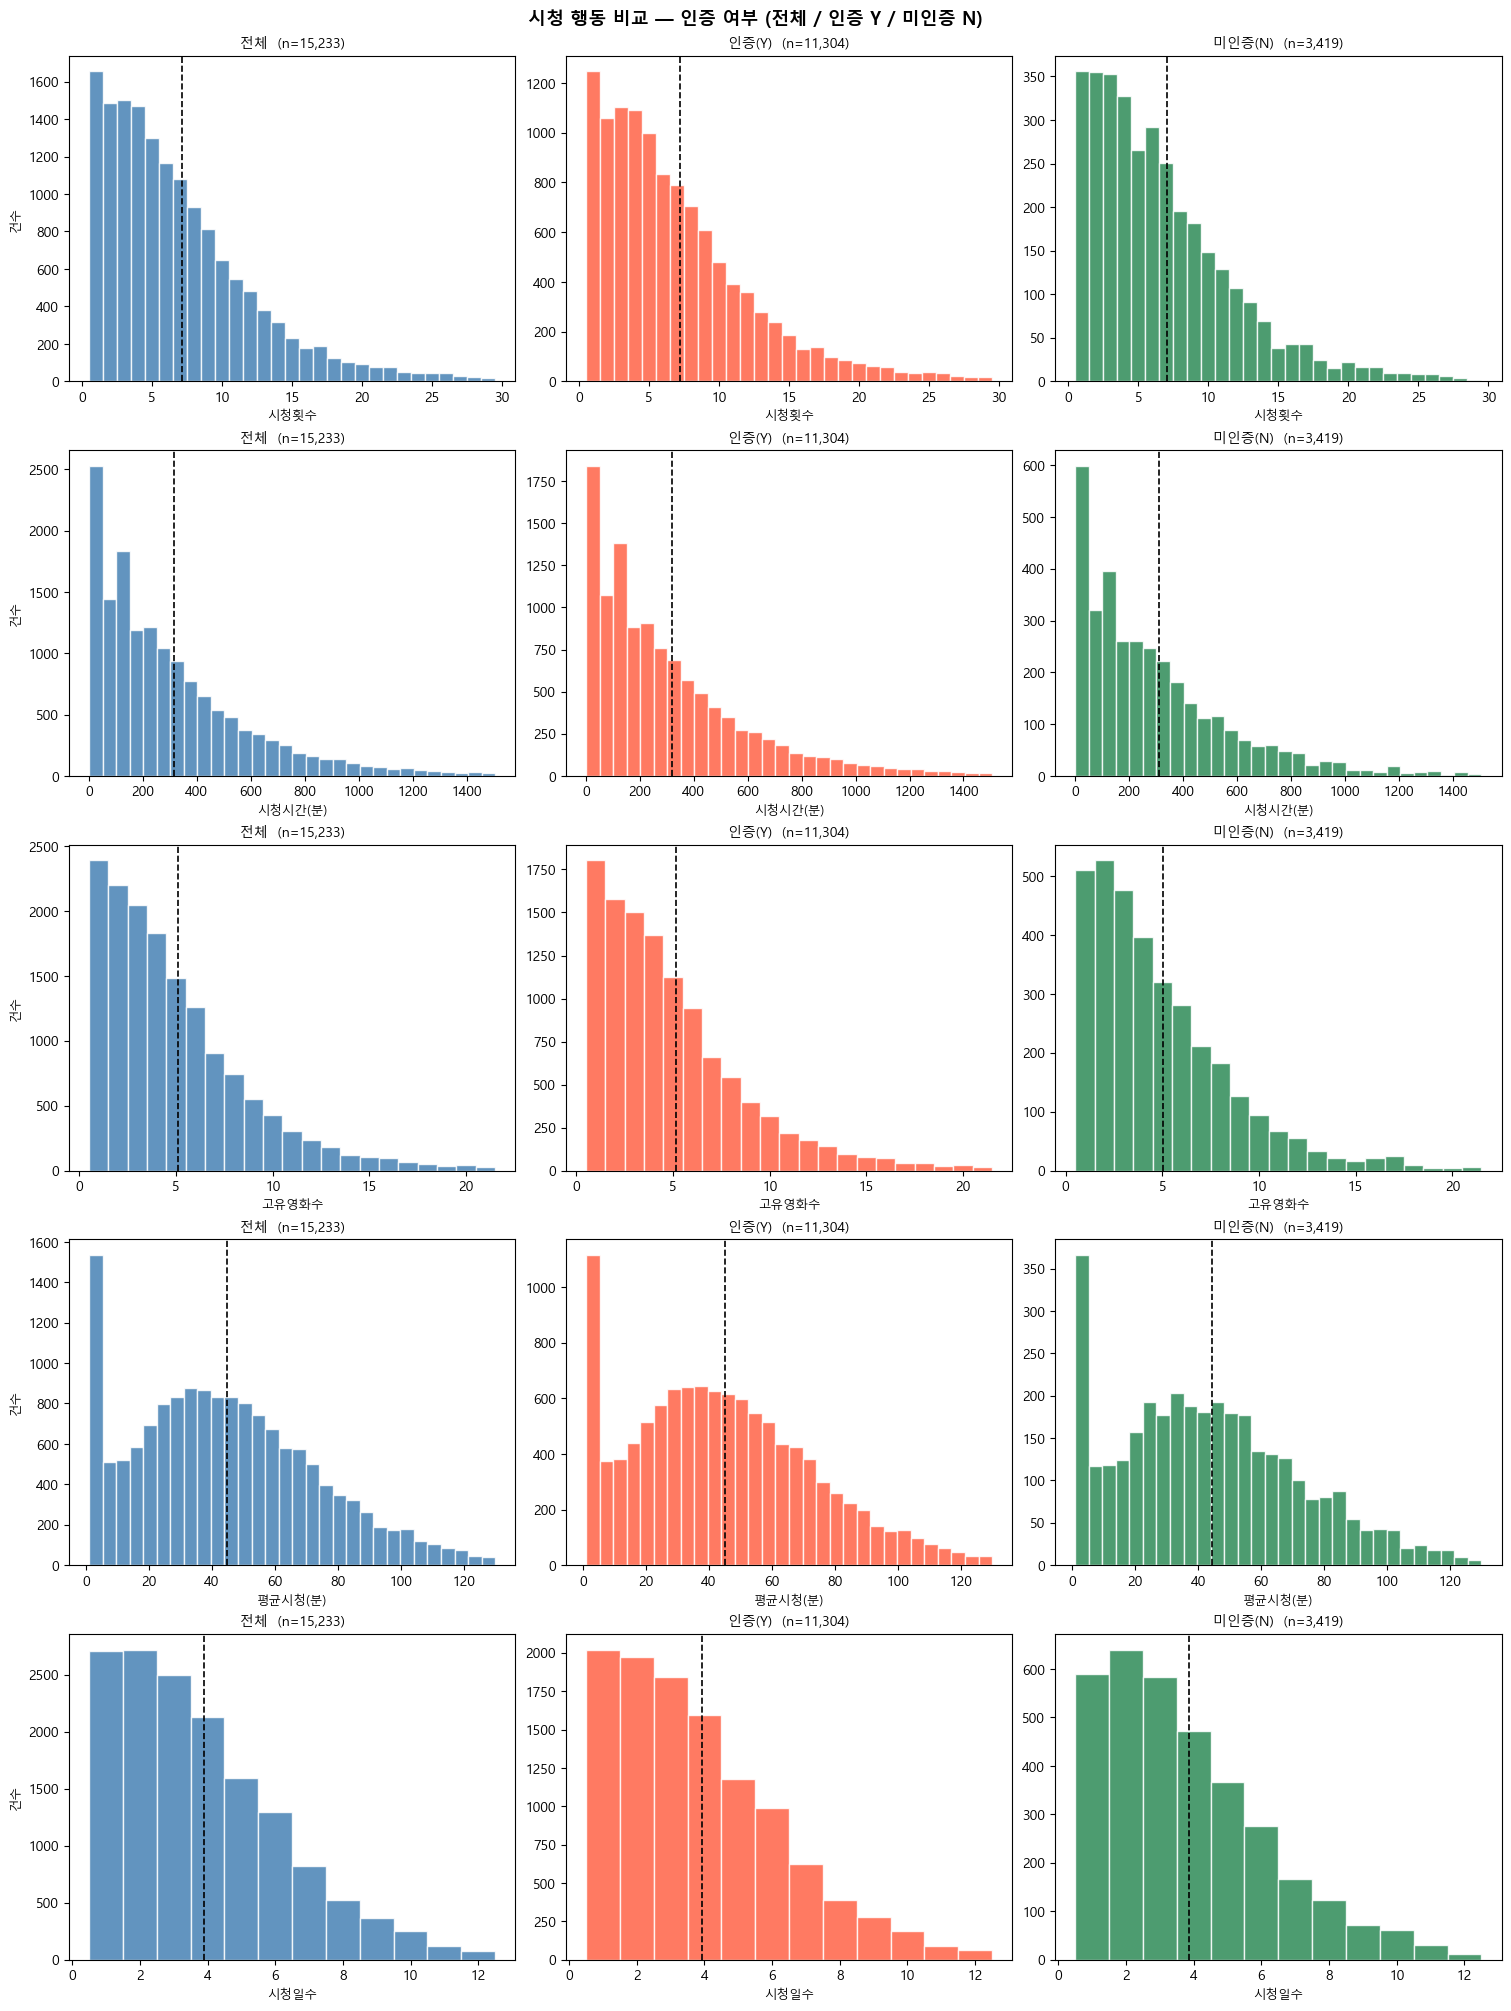

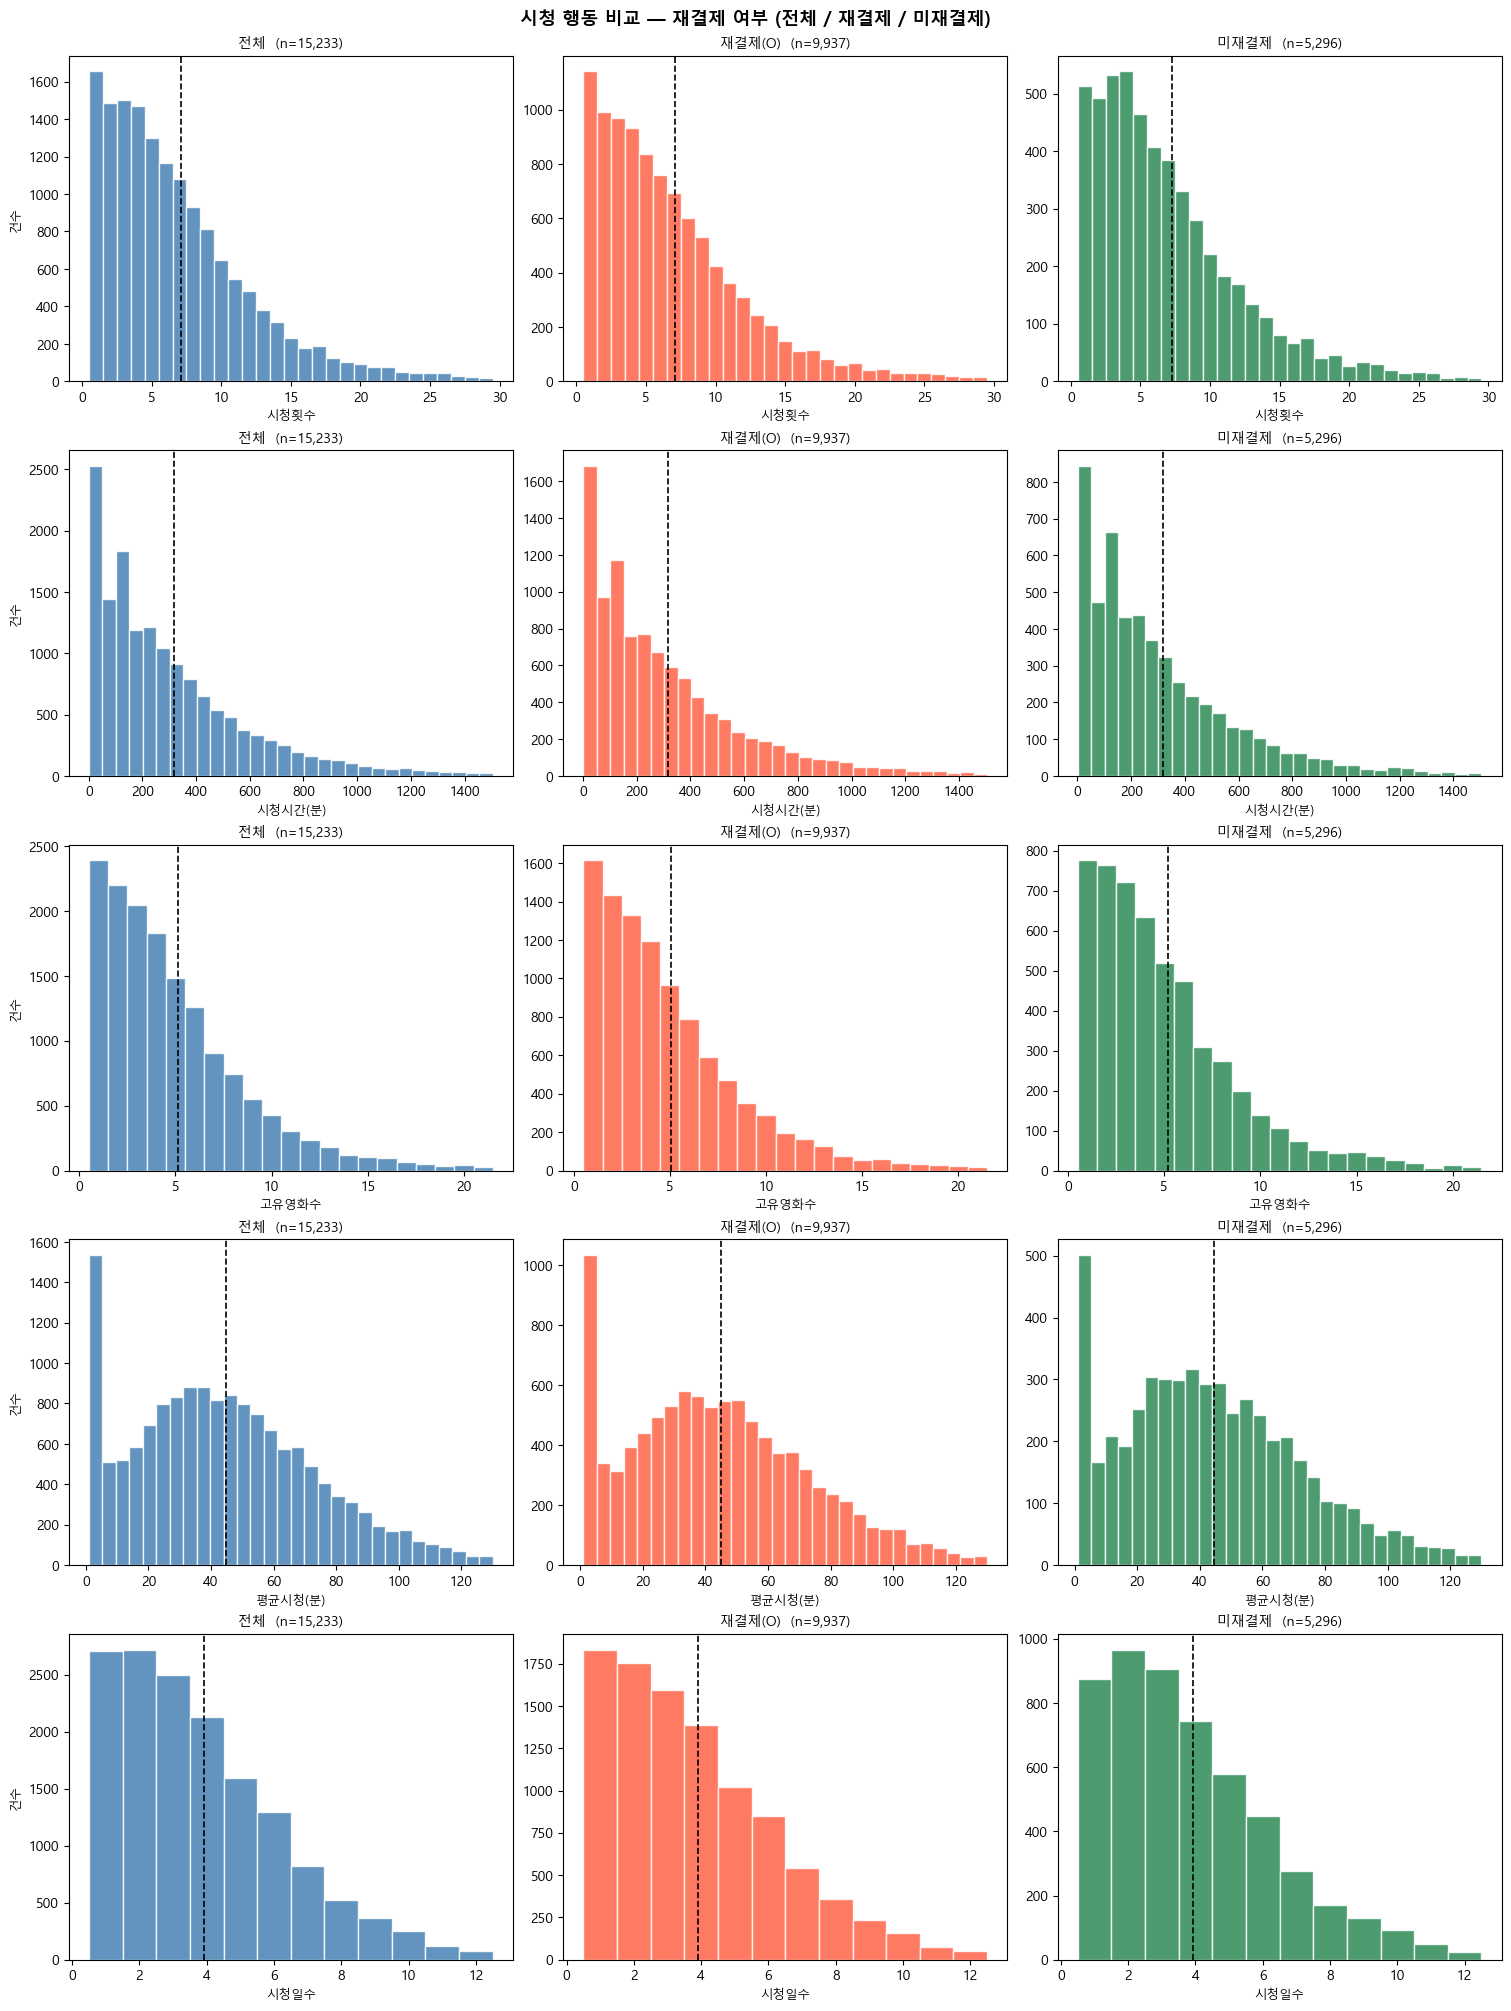

In [55]:
import numpy as np

# 정수형 변수는 정수 단위 bin, 연속형은 linspace
int_feats = {'total_watch_count', 'unique_movies', 'watch_days'}

def get_bins(vals_all, fc):
    lo = vals_all.min()
    hi = vals_all.quantile(0.99)
    if fc in int_feats:
        return np.arange(int(lo), int(hi) + 2) - 0.5
    return np.linspace(lo, hi, 31)

def plot_seg_separate(seg_dict, feat_cols, feat_labels, sup_title):
    nrows = len(feat_cols)
    seg_keys = list(seg_dict.keys())
    colors = ['steelblue', 'tomato', 'seagreen']
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 4 * nrows),
                             constrained_layout=True)
    for r, (fc, fl) in enumerate(zip(feat_cols, feat_labels)):
        all_vals = pd.concat([seg_dict[k][fc].dropna() for k in seg_keys])
        bins = get_bins(all_vals, fc)
        for c, (key, color) in enumerate(zip(seg_keys, colors)):
            ax = axes[r, c]
            vals = seg_dict[key][fc].dropna()
            ax.hist(vals, bins=bins, color=color, edgecolor='white', alpha=0.85)
            ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2)
            ax.set_title(f'{key}  (n={len(vals):,})', fontsize=10)
            ax.set_xlabel(fl, fontsize=9)
            if c == 0:
                ax.set_ylabel('건수', fontsize=9)
    fig.suptitle(sup_title, fontsize=13, fontweight='bold')
    plt.show()

feat_cols   = ['total_watch_count', 'total_watch_duration', 'unique_movies', 'avg_duration', 'watch_days']
feat_labels = ['시청횟수', '시청시간(분)', '고유영화수', '평균시청(분)', '시청일수']
has = merged[merged['has_watch'] == 1]

plot_seg_separate(
    {'전체': has, '인증(Y)': has[has['is_user_verified']=='Y'], '미인증(N)': has[has['is_user_verified']=='N']},
    feat_cols, feat_labels,
    '시청 행동 비교 — 인증 여부 (전체 / 인증 Y / 미인증 N)')

plot_seg_separate(
    {'전체': has, '재결제(O)': has[has['repurchase']=='O'], '미재결제': has[has['repurchase'].isna()]},
    feat_cols, feat_labels,
    '시청 행동 비교 — 재결제 여부 (전체 / 재결제 / 미재결제)')
